<a href="https://colab.research.google.com/github/hberkaycoser-hash/HBC/blob/main/E%26PB_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


→ Please upload your all_street.xlsx file:


Saving all_street-3.xlsx to all_street-3.xlsx
✓ Loaded: all_street-3.xlsx

██████████████████████████████████████████████████████████████████████
█  GENERATING ALL MANUSCRIPT OUTPUTS
█  Safety_3Cat thresholds: ≤17.55 (Low) / ≤20.50 (Middle) / >20.50 (High)
██████████████████████████████████████████████████████████████████████

✓ Output folder: /content/manuscript_outputs
✓ Matched streets : 74 / 74
✓ Feature count   : 12
✓ Safe=37 | Unsafe=37
✓ Low=37 | Middle=16 | High=21
✓ Safety_3Cat distribution (37 / 16 / 21) matches manuscript Figure S5
✓ PCA: PC1 = 21.5%, PC2 = 17.8%
✓ Cluster sizes (after re-ordering): [23, 46, 5]

[Table 2] Descriptive statistics ... ✓
[Figure 3] Silhouette k=2..10 ... 

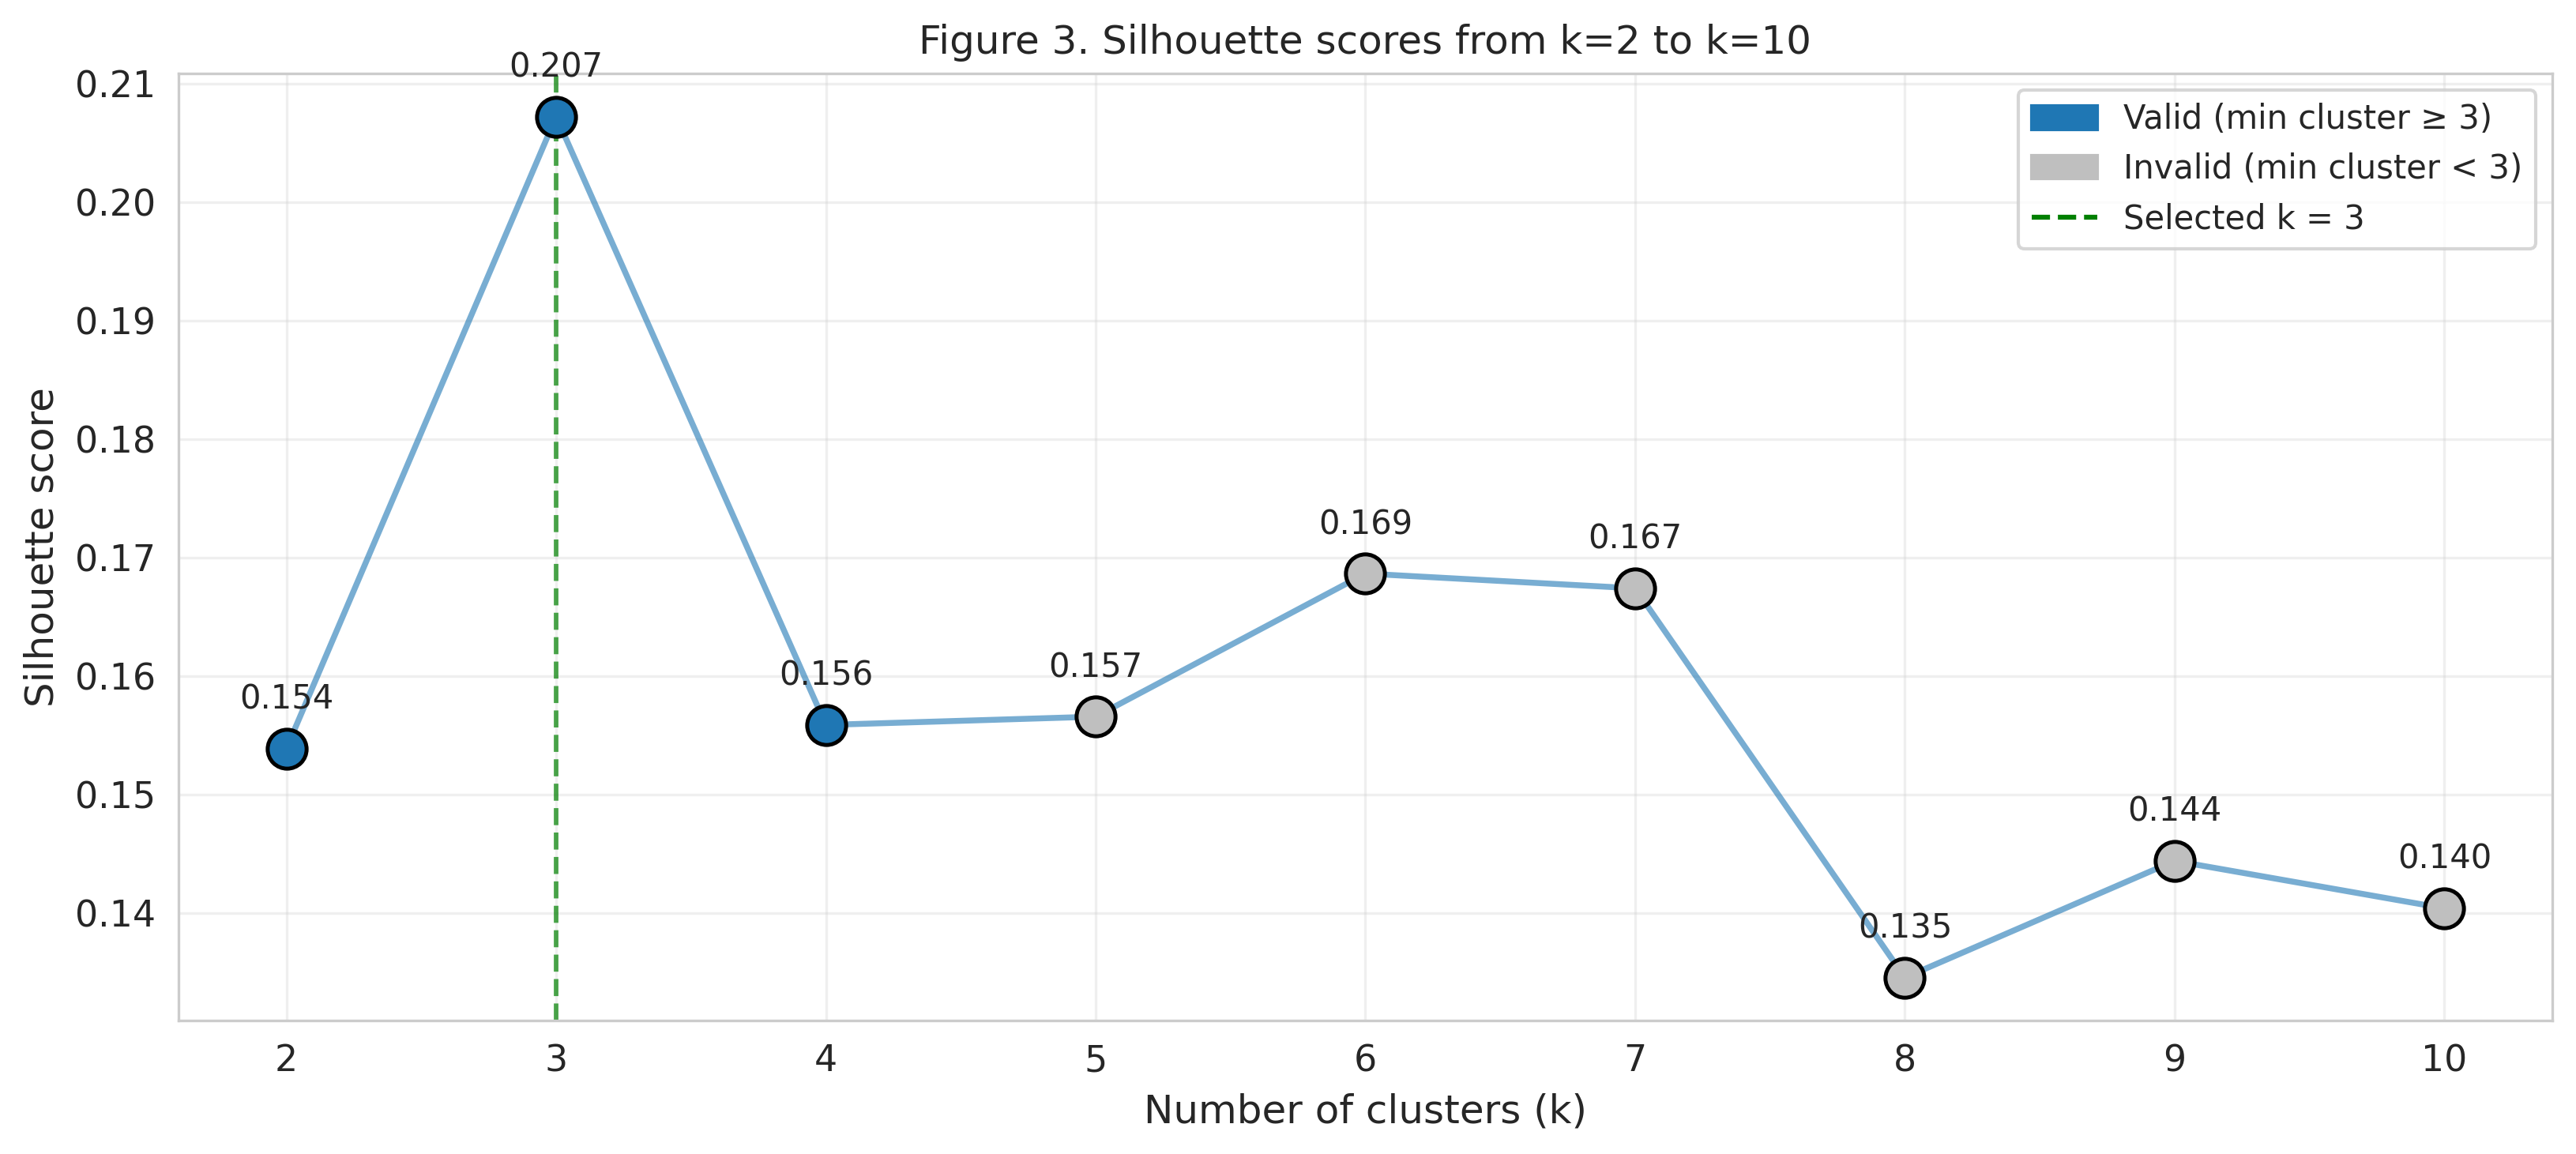

✓
[Figure 4] Cluster centroids ... 

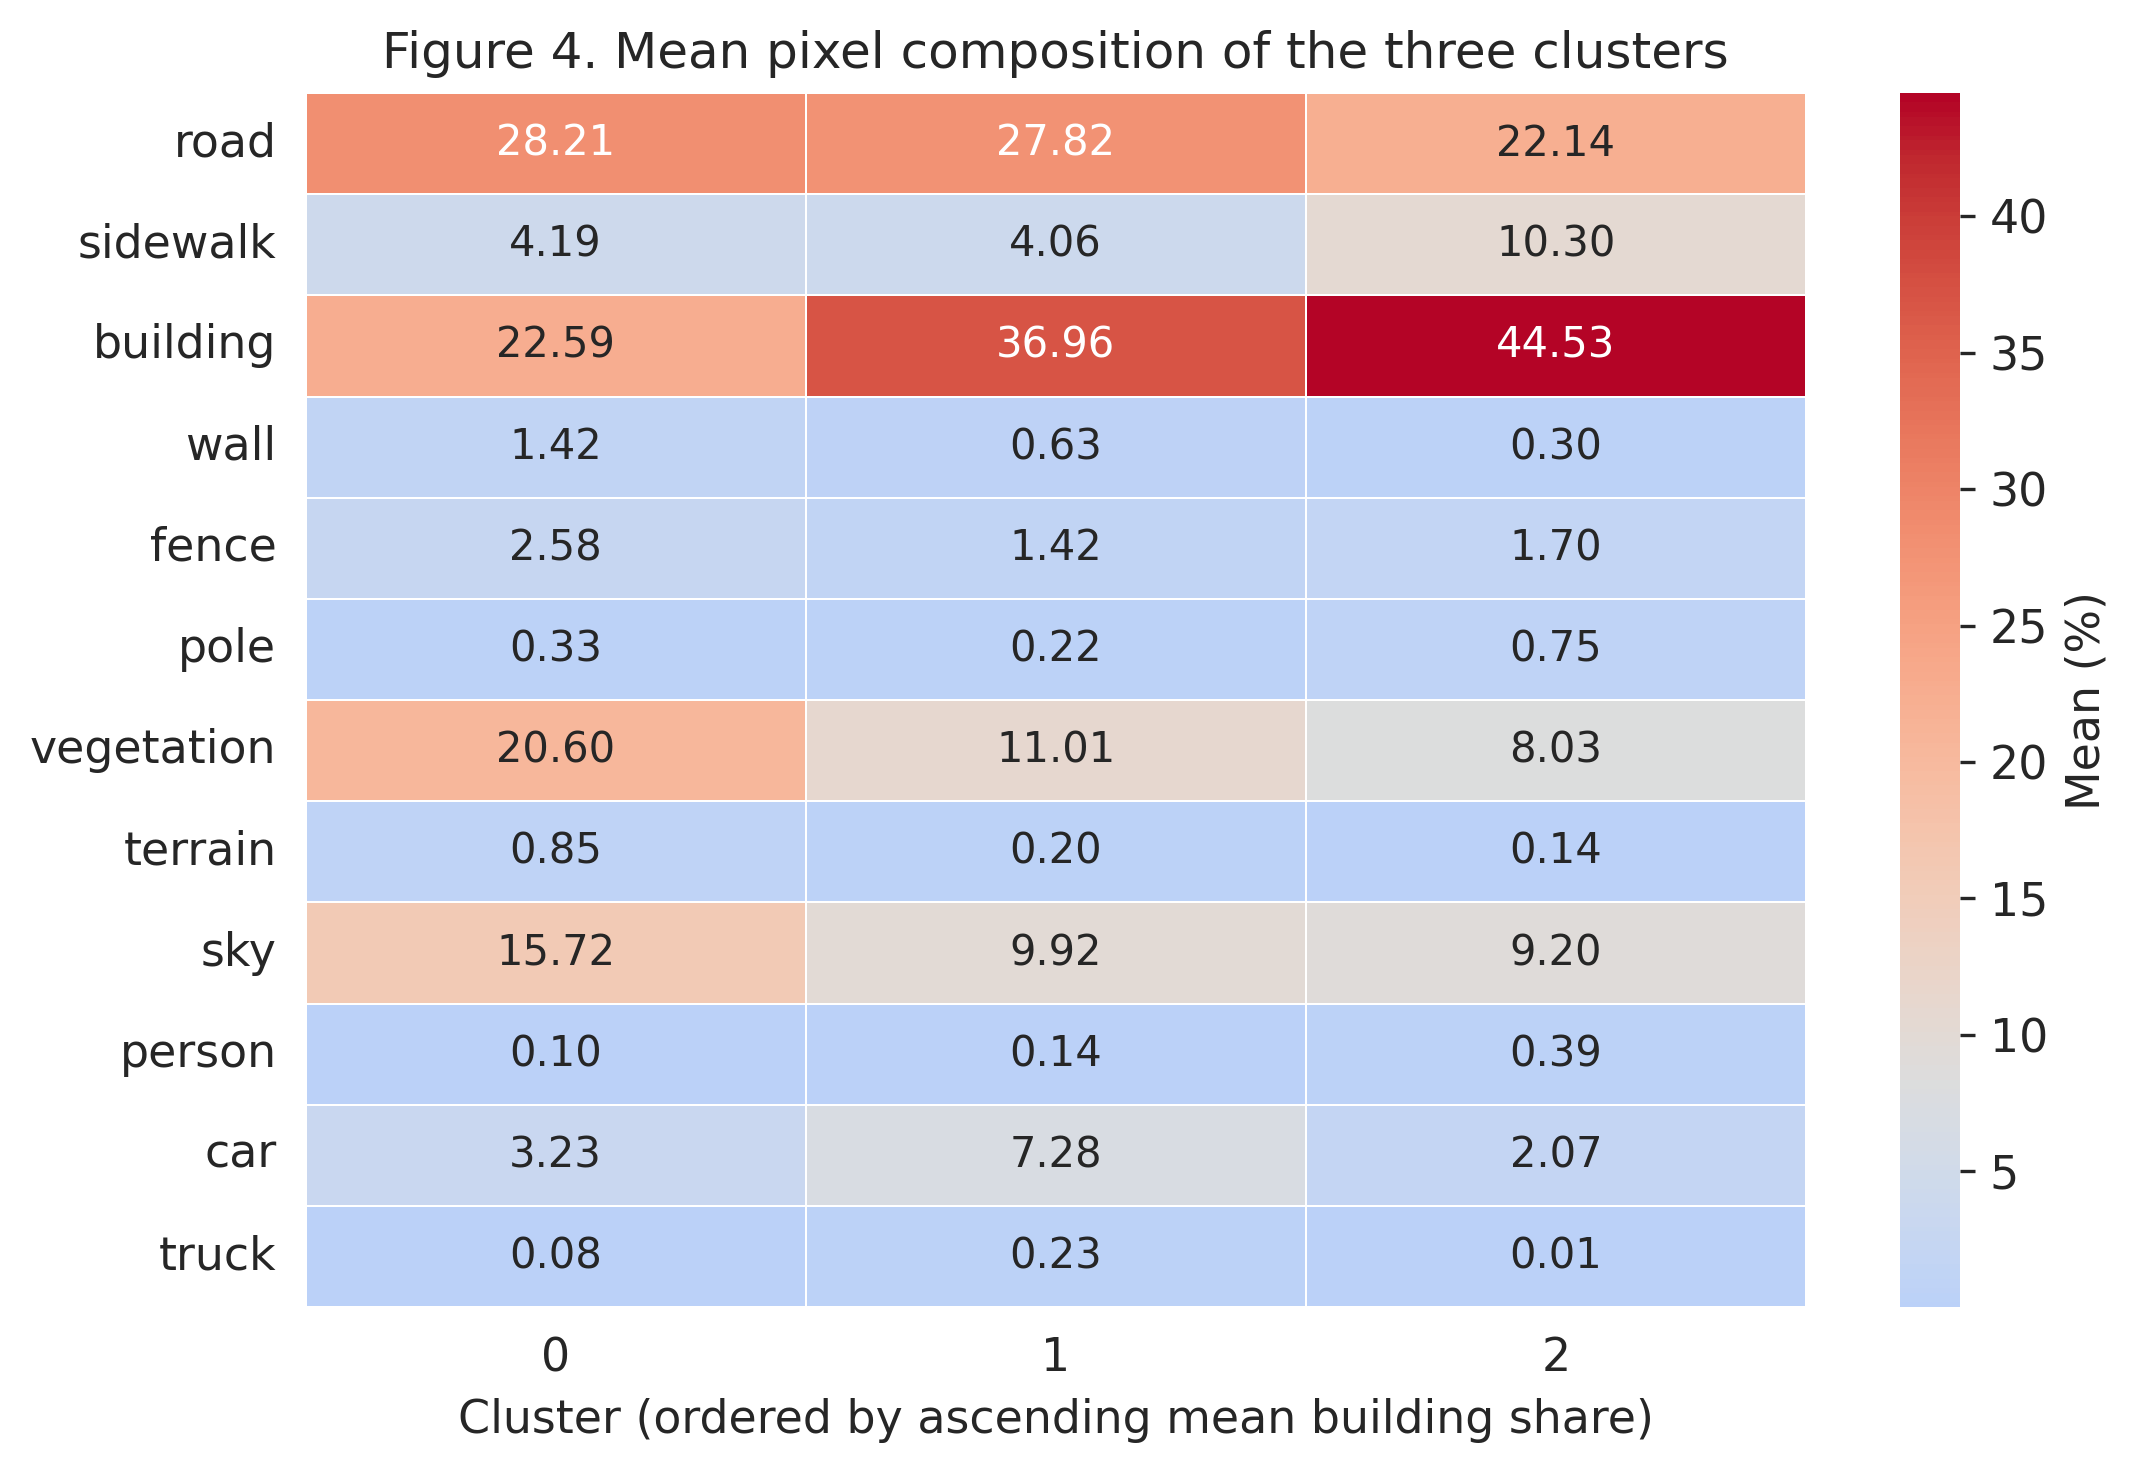

✓
[Figure 5] PCA Safe/Unsafe × Cluster ... 

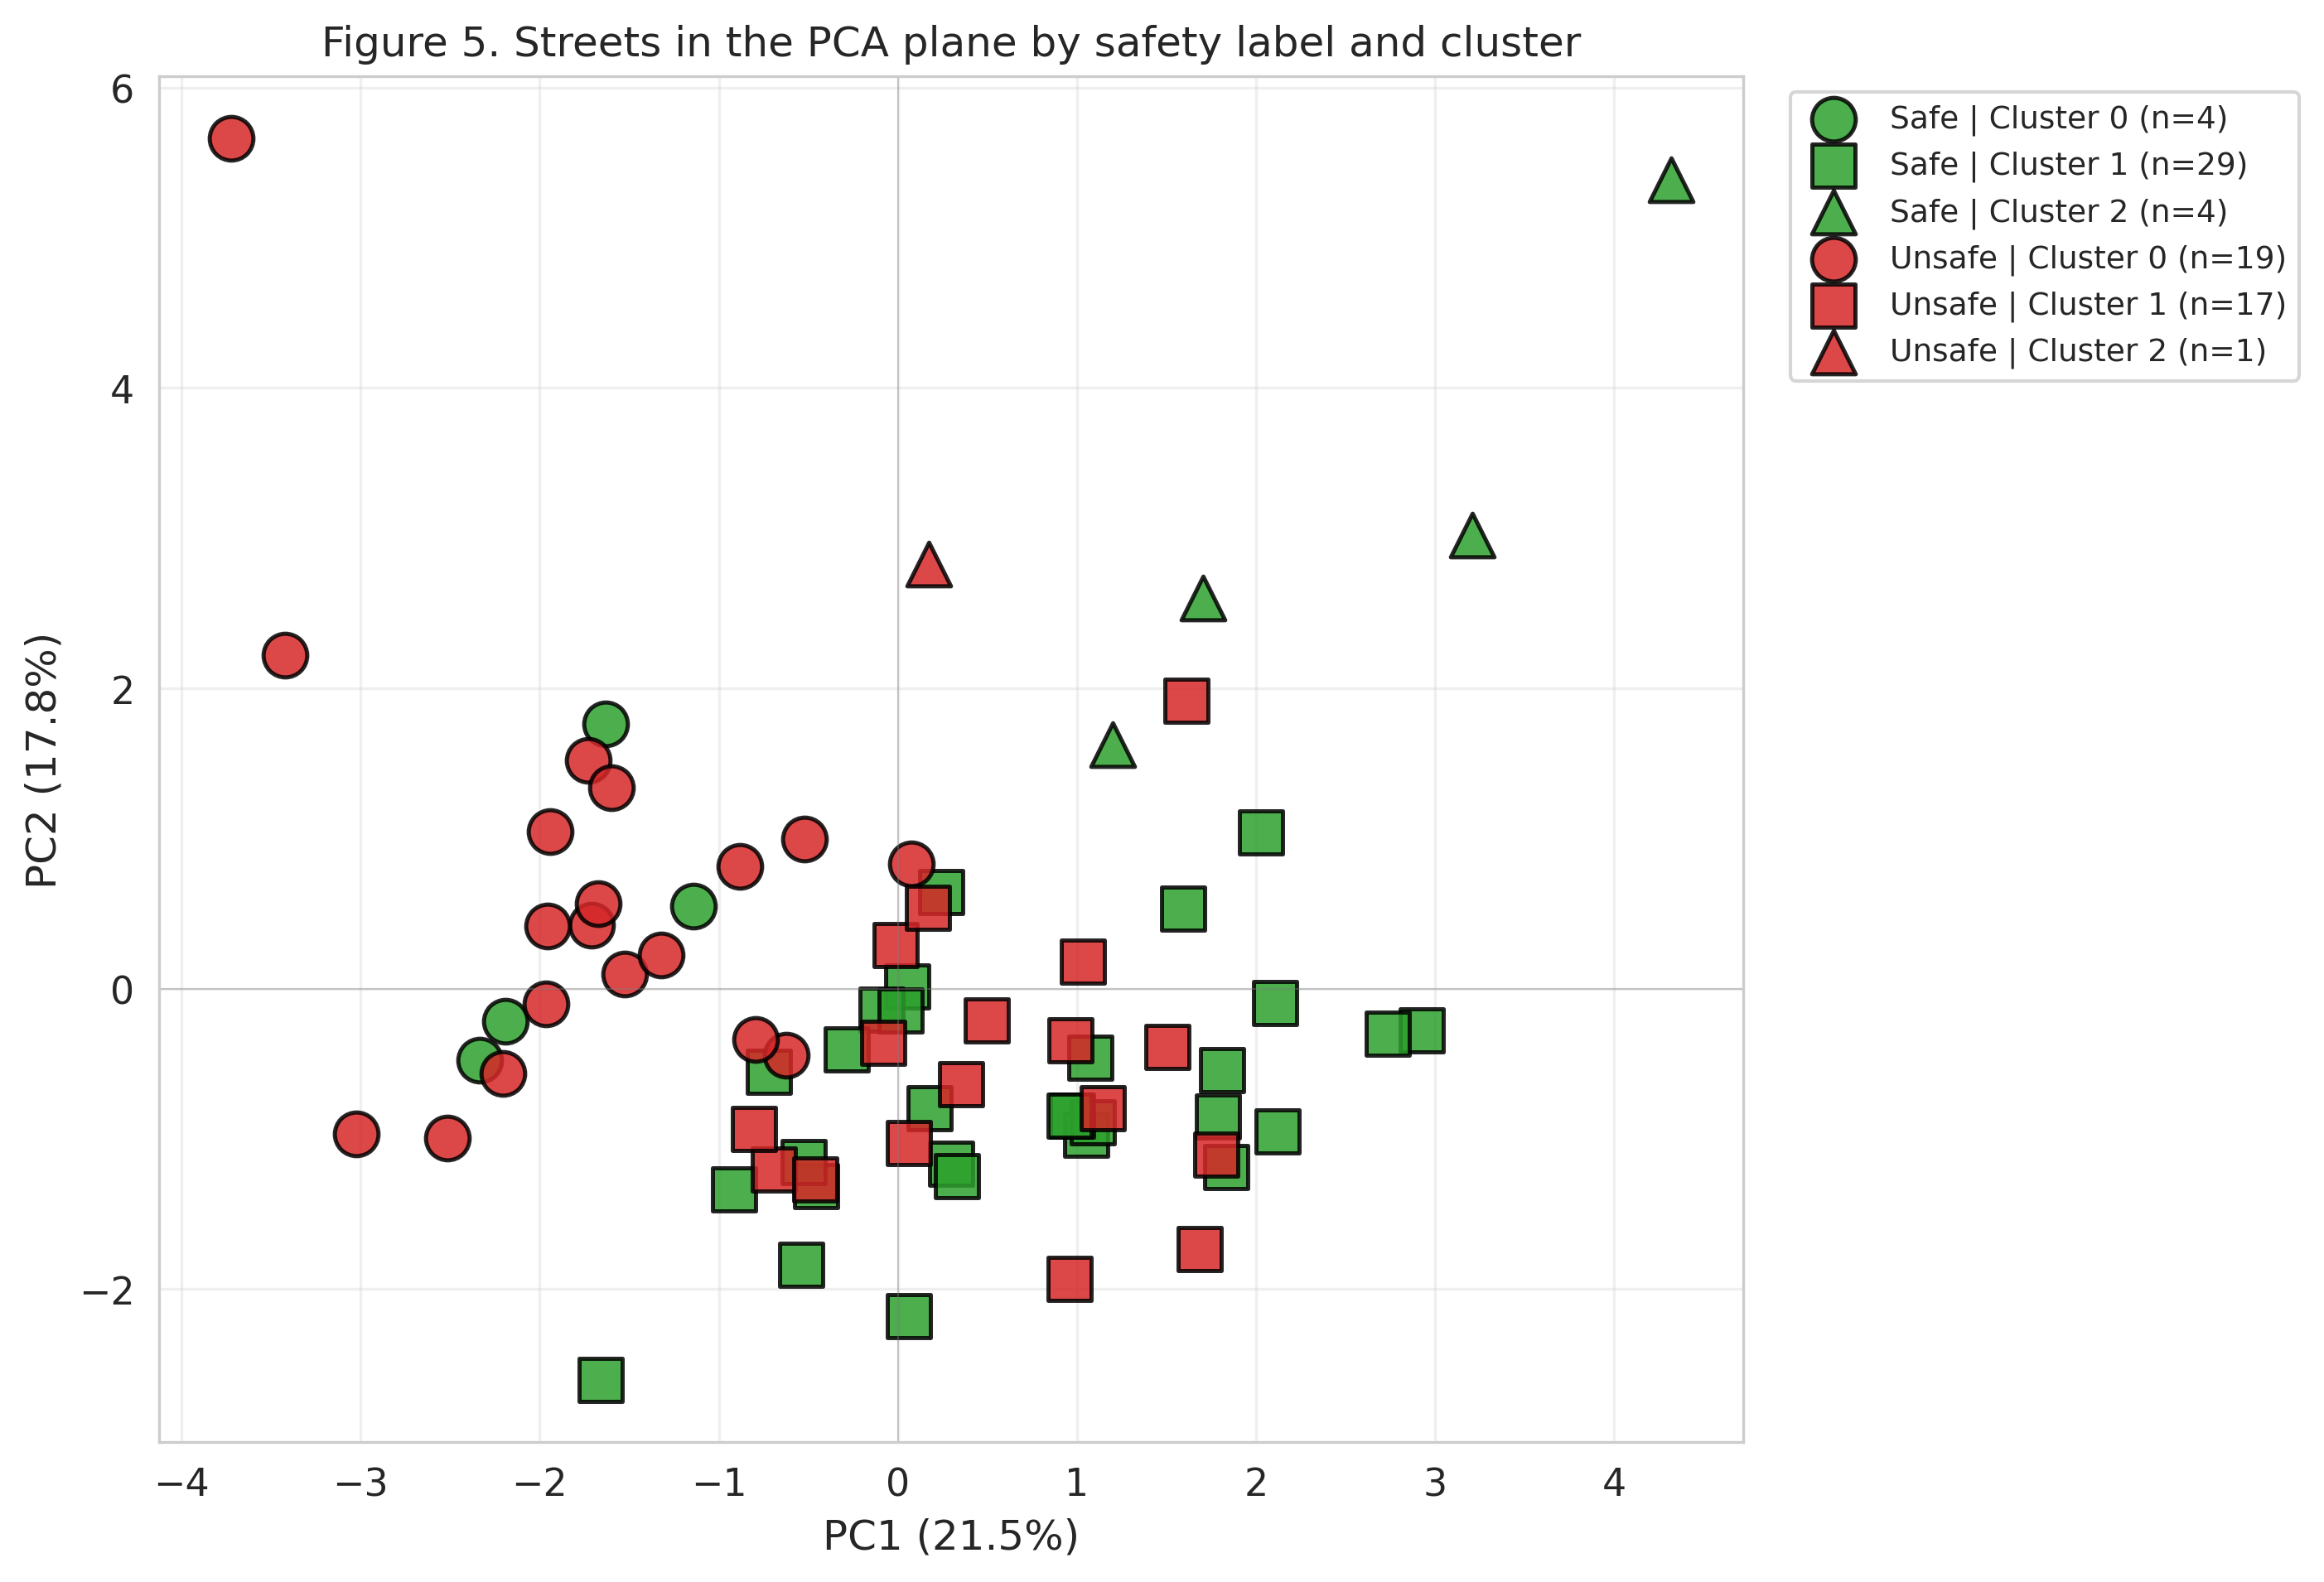

✓
[Figure 6] Cluster × 3-band safety ... 

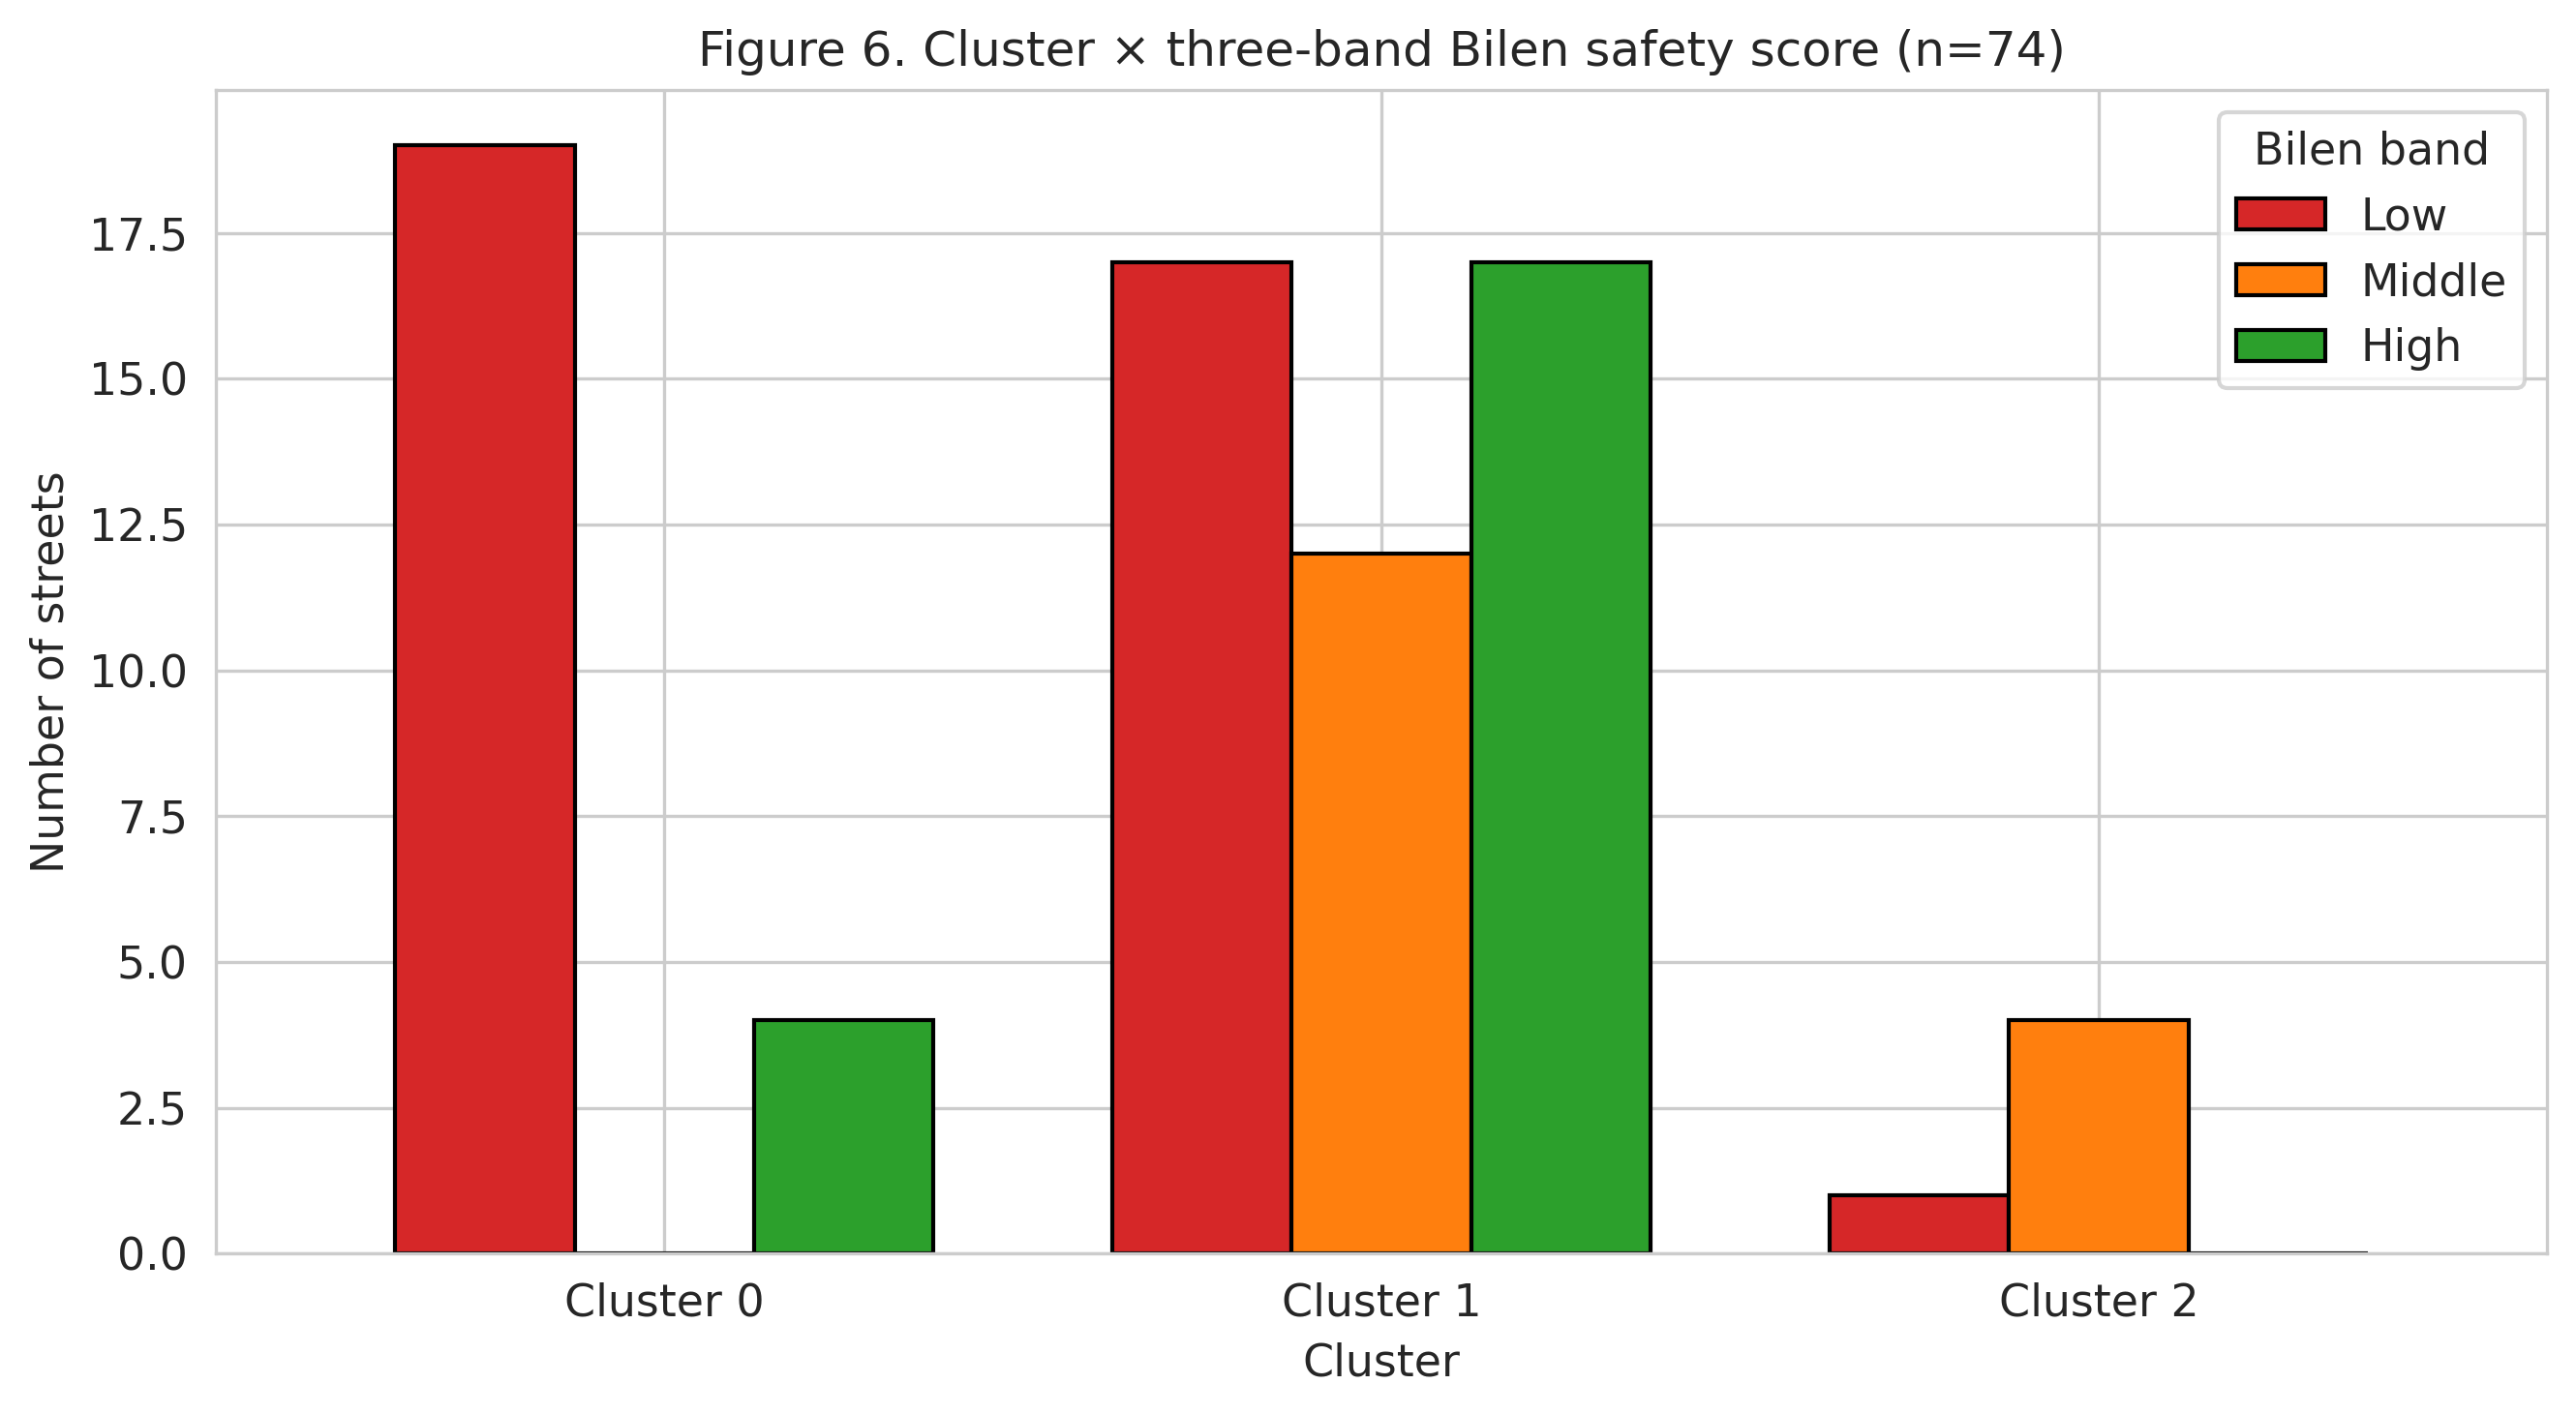

✓ (Cluster 0: {'Low': 19, 'Middle': 0, 'High': 4})
[Figure 7] Spearman correlations ... 

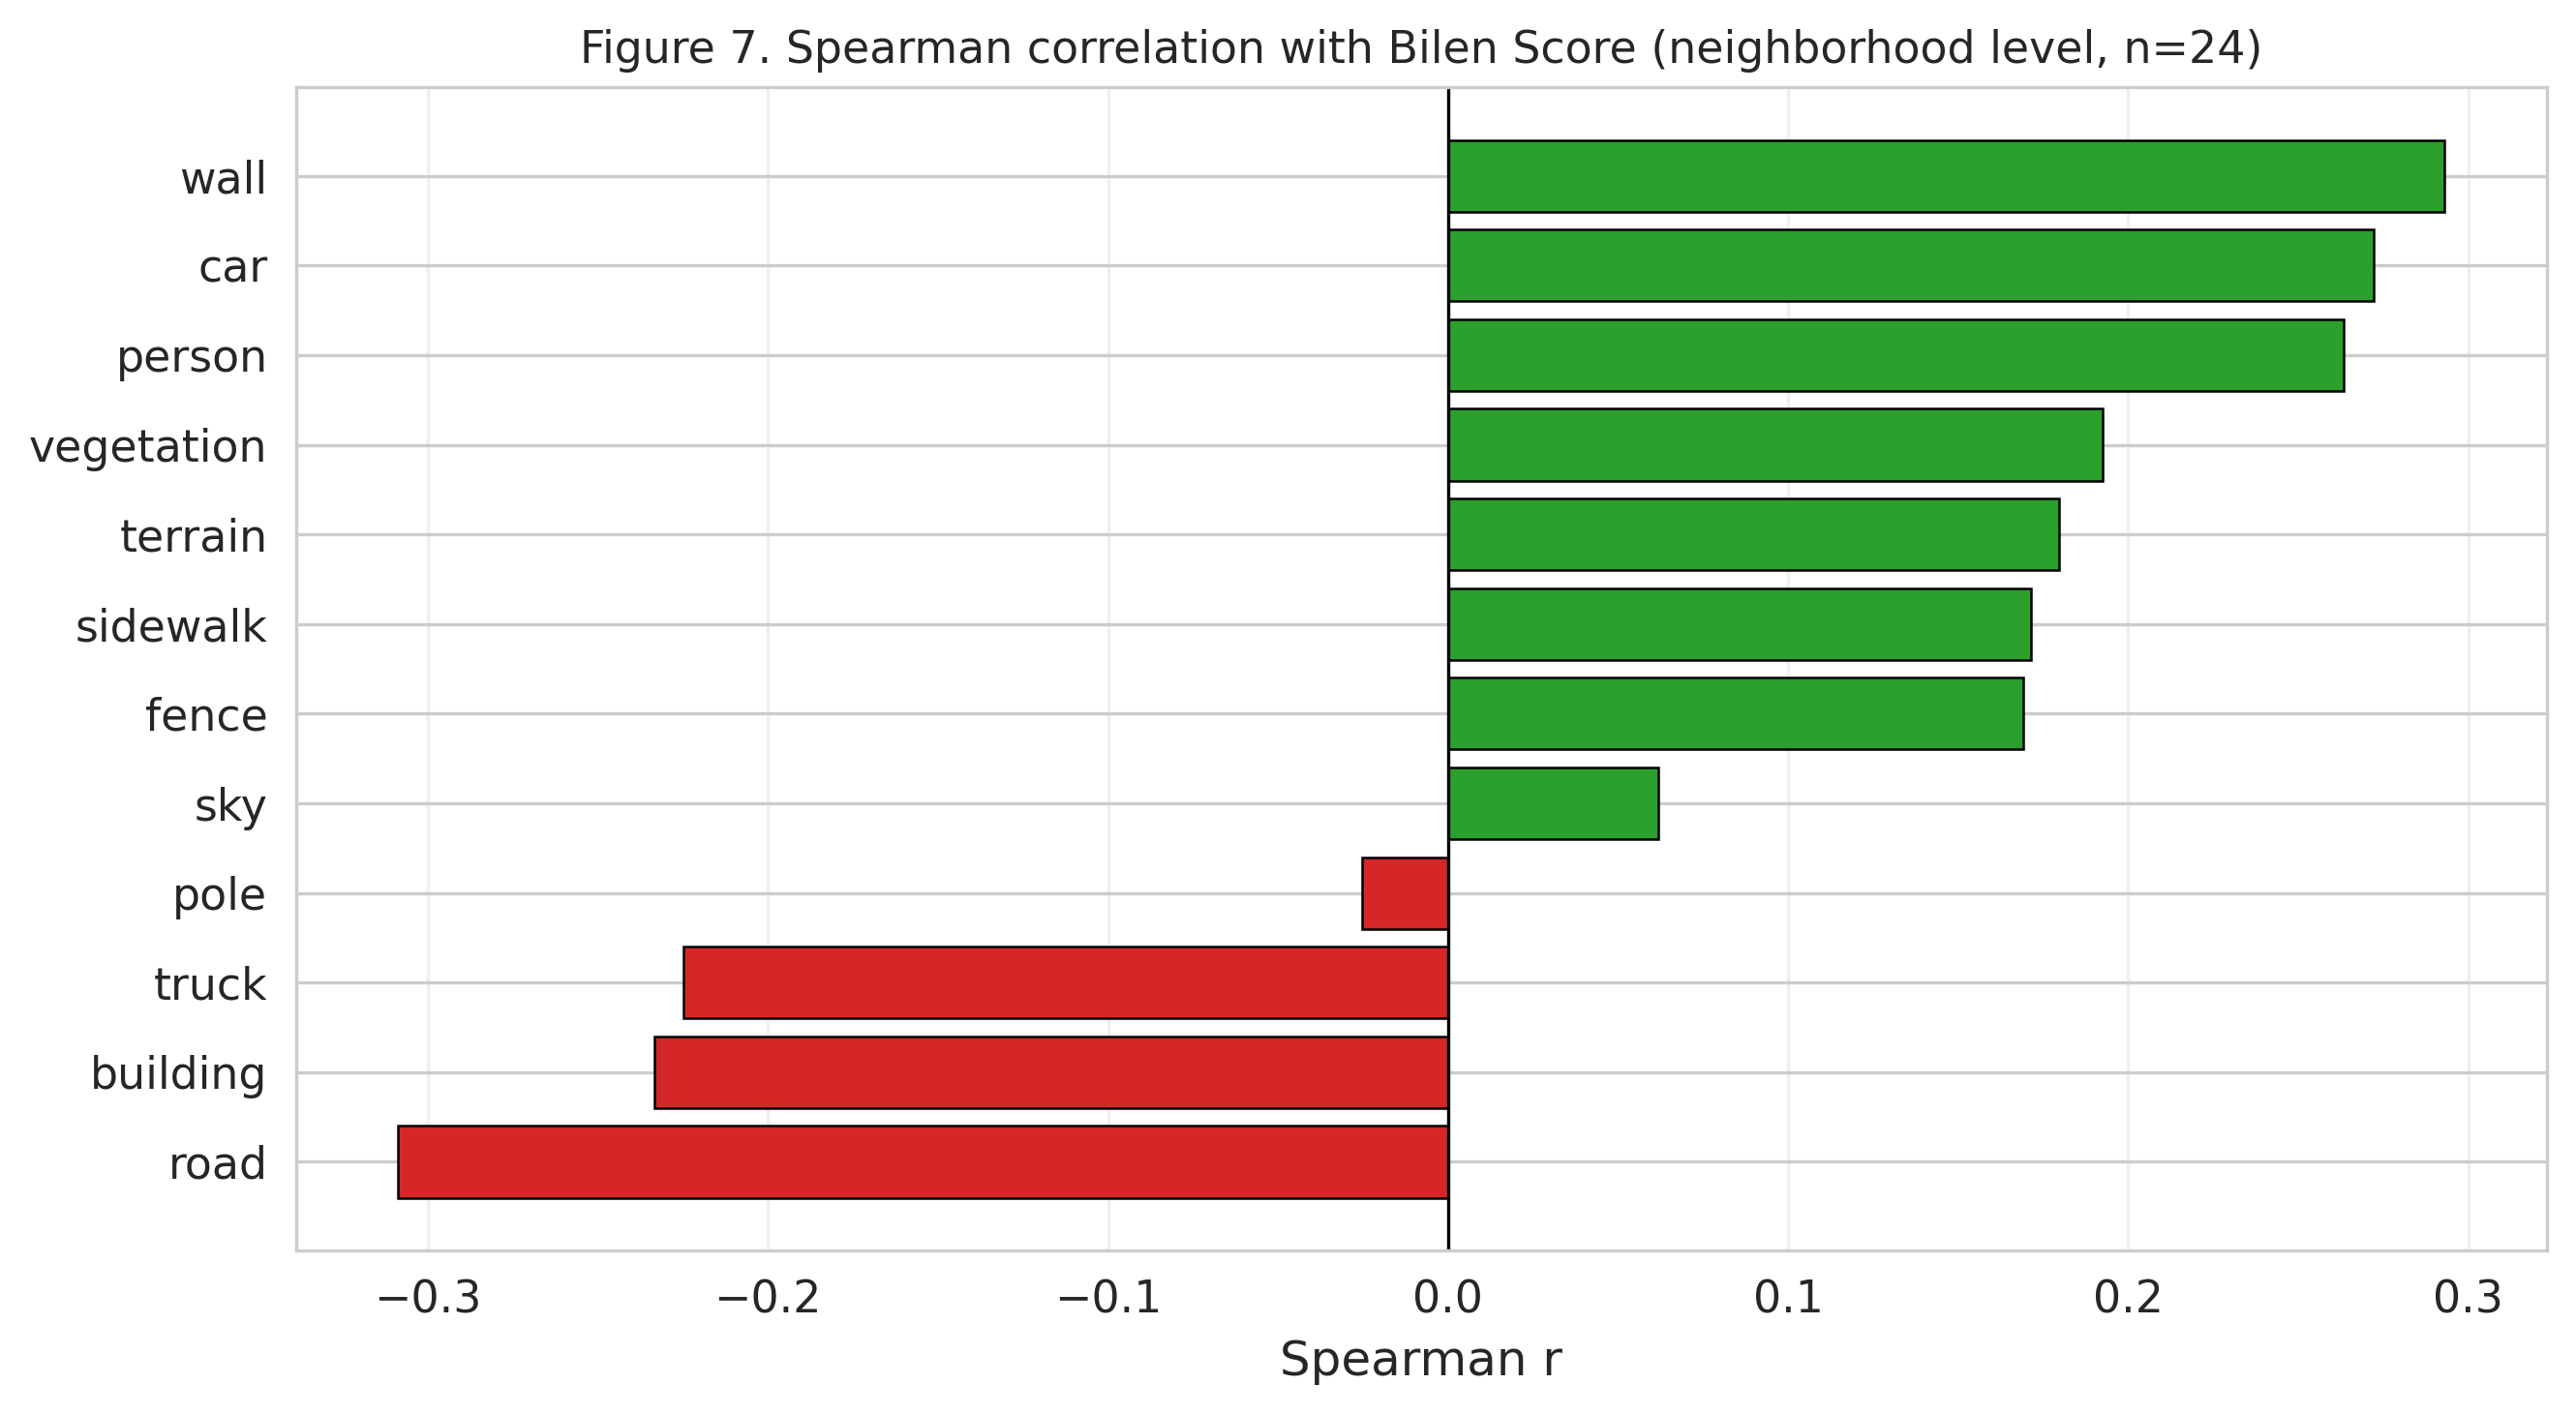

✓

--- Extended analysis (for Figure 8 + Tables S6/S7/S8/S9) ---
[HDBSCAN] sweep mcs 3..7 ... ✓ (best mcs=3, noise=33.8%)
[GMM] sweep k 2..7 by BIC ... ✓ (best k=7)
[Hierarchical] Ward, k=3 ... ✓ (cophenetic=0.382)
[Figure 8] ARI matrix ... 

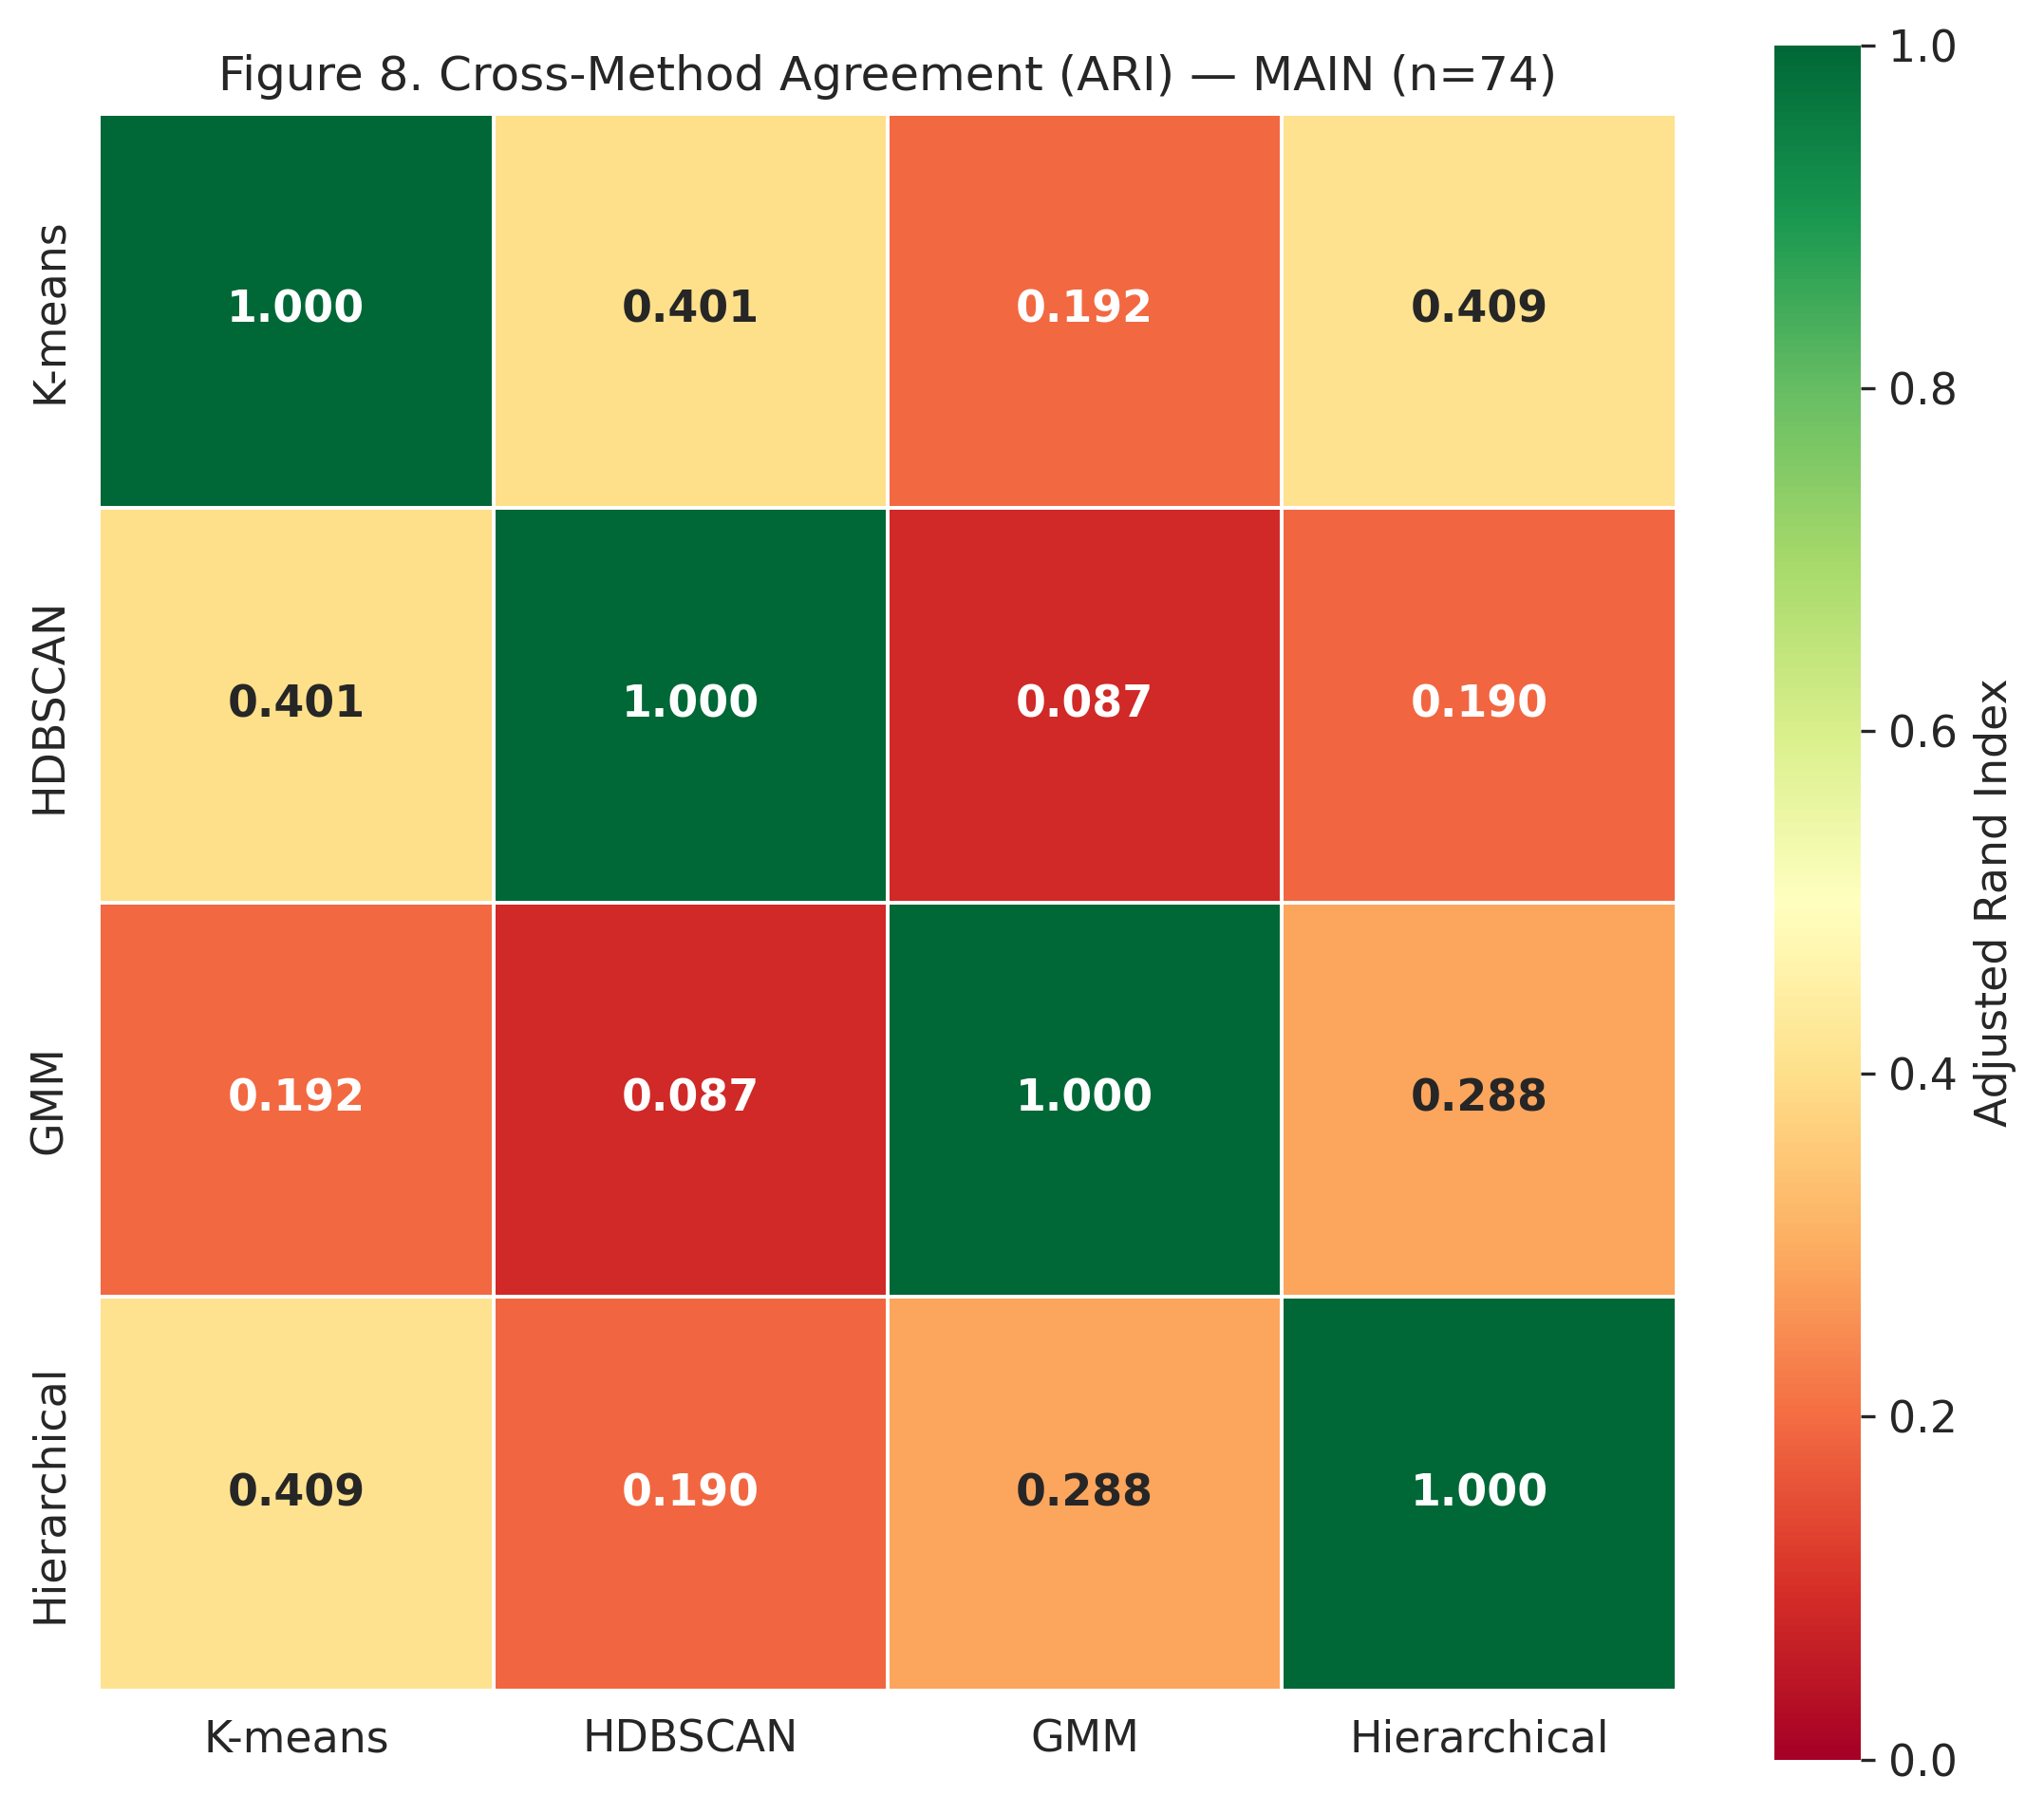

✓
[Figure 9] Consensus matrix (1000 bootstraps) ... 

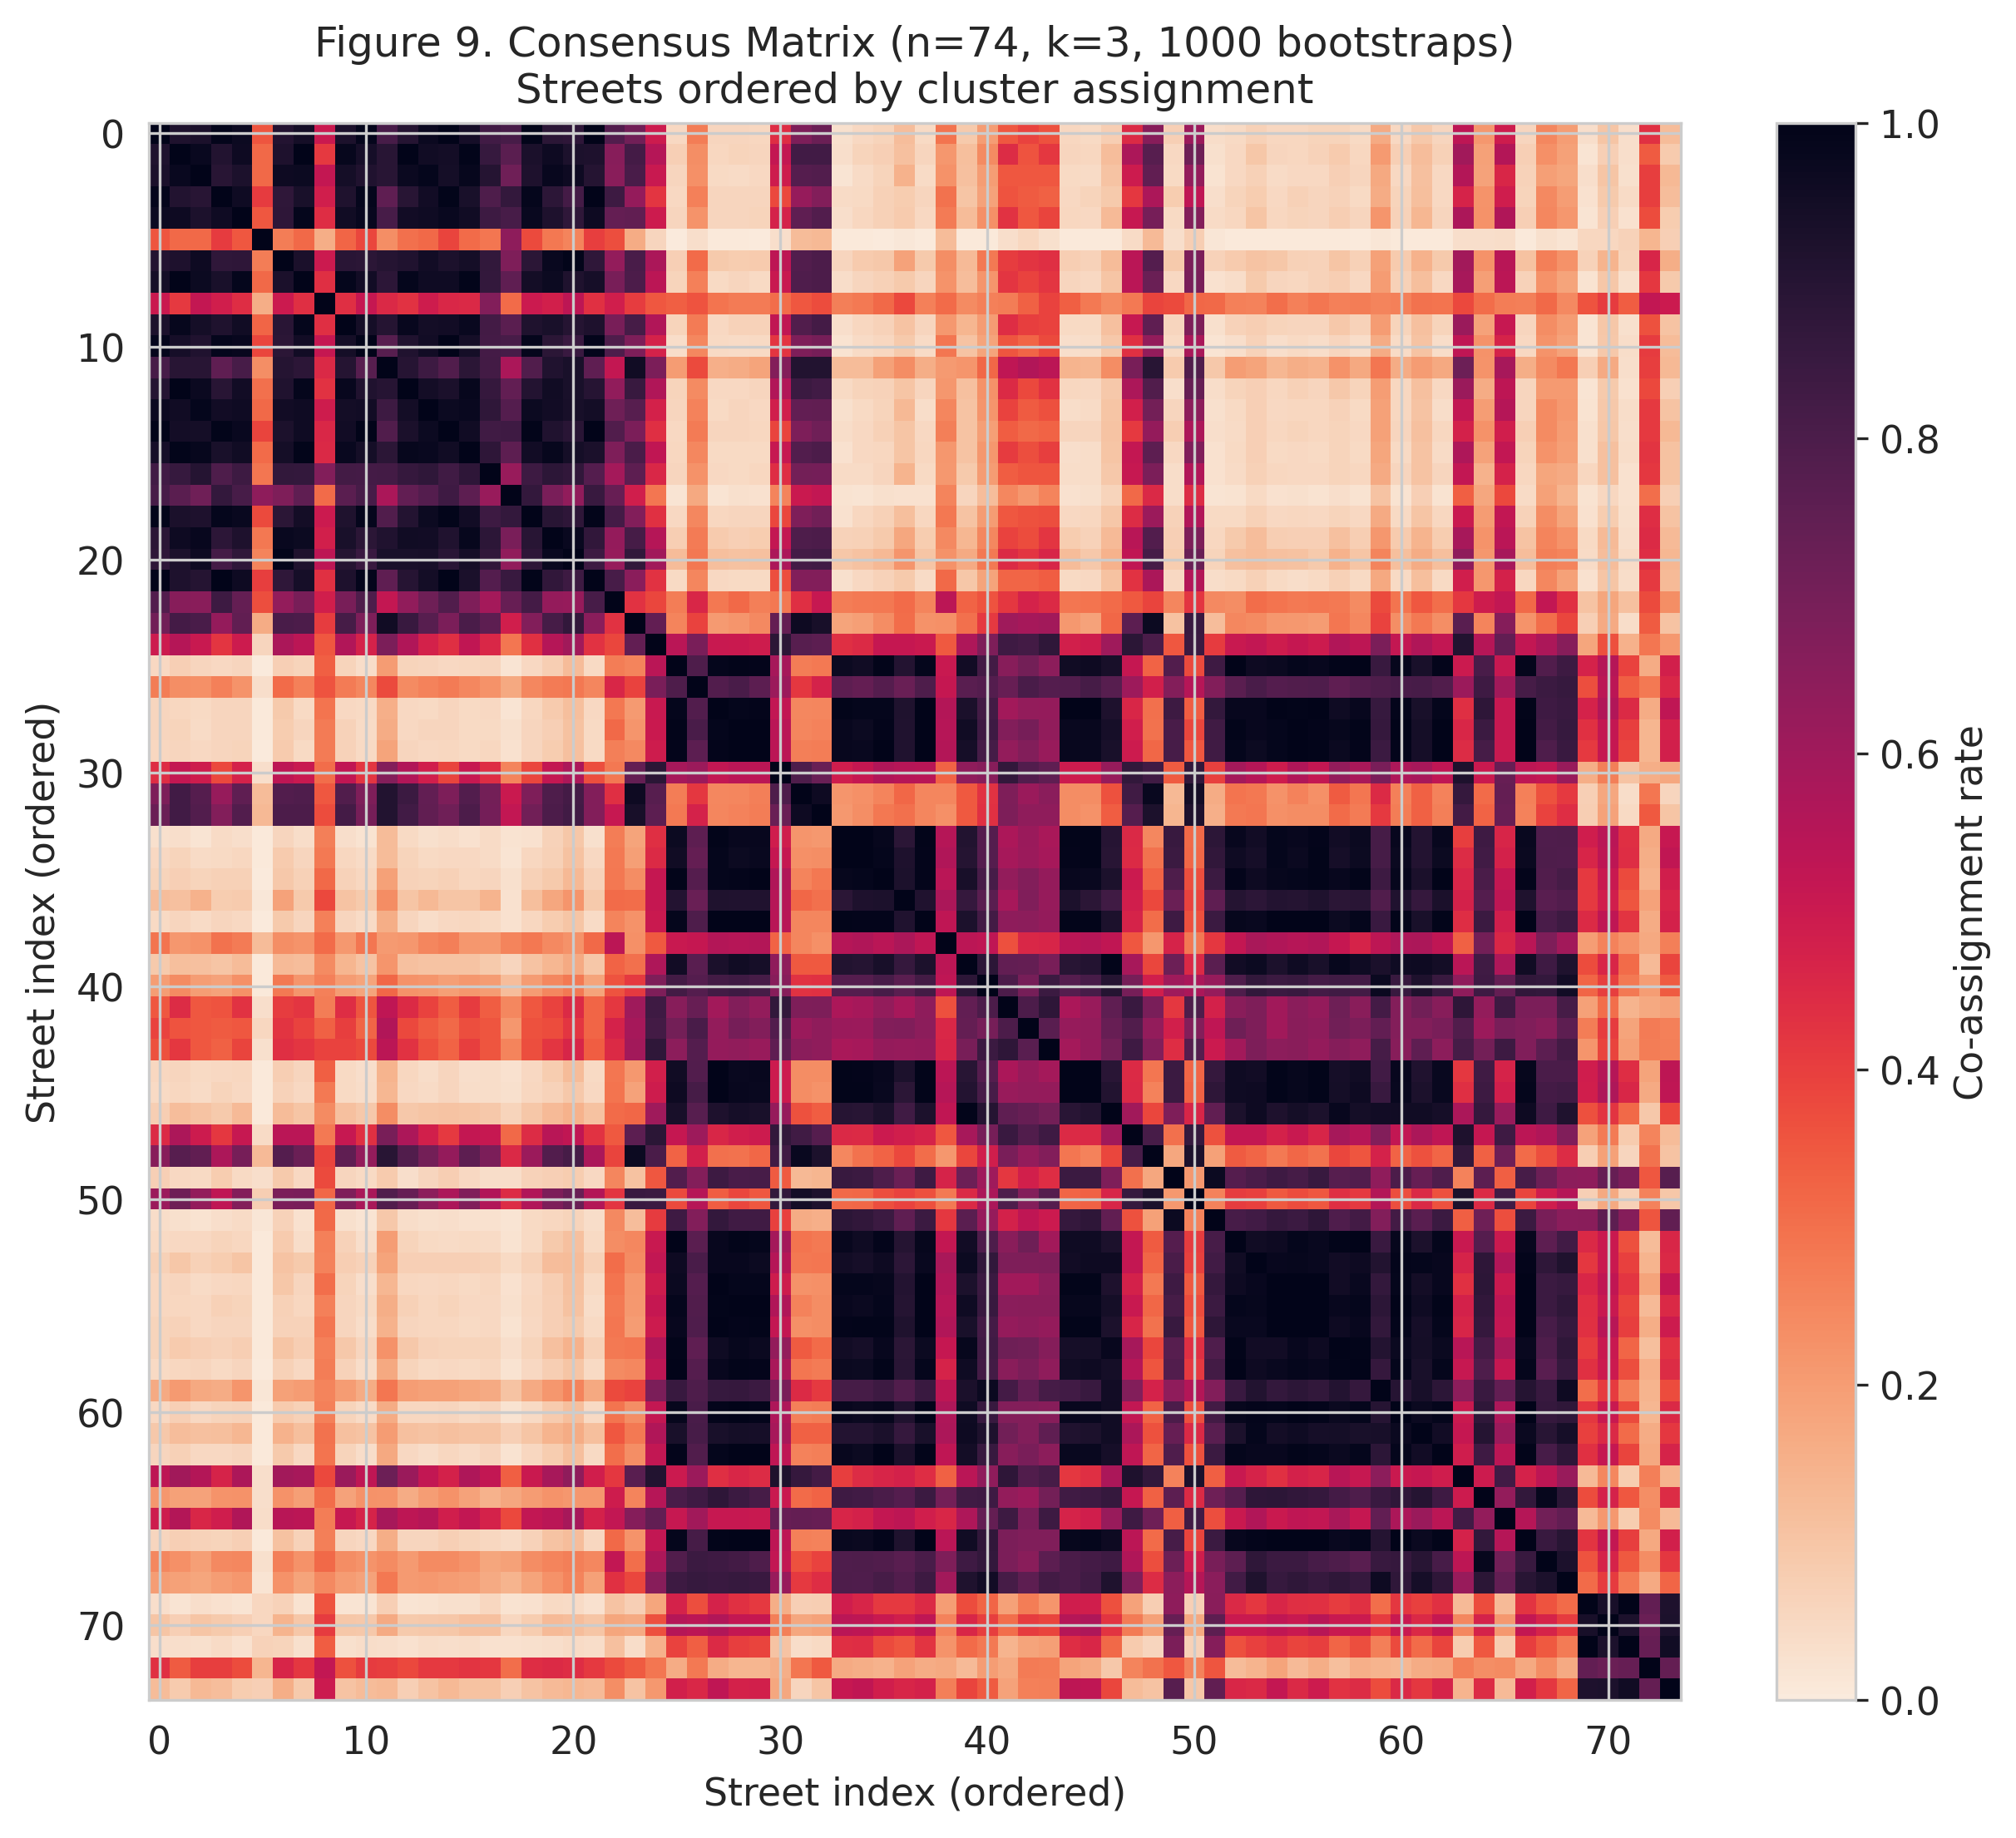

✓
[Table S1] Spearman ... ✓
[Table S2] Logistic regression ... ✓ (acc=0.838, McFadden=0.303)
[Table S3] Kruskal-Wallis + FDR ... ✓ (6/12 significant)
[Table S4] Sensitivity (Firüzköy excluded) ... ✓ (main boot=675 / 2701 (25.0%), sens boot=348 / 1770 (19.7%))
[Table S5] QC process ... ✓
[Table S6] HDBSCAN sweep ... ✓
[Table S7] GMM sweep ... ✓
[Table S8] ARI matrix ... ✓
[Table S9] Hybrid-fabric summary ... ✓
[Figure S4] Silhouette without Firüzköy ... 

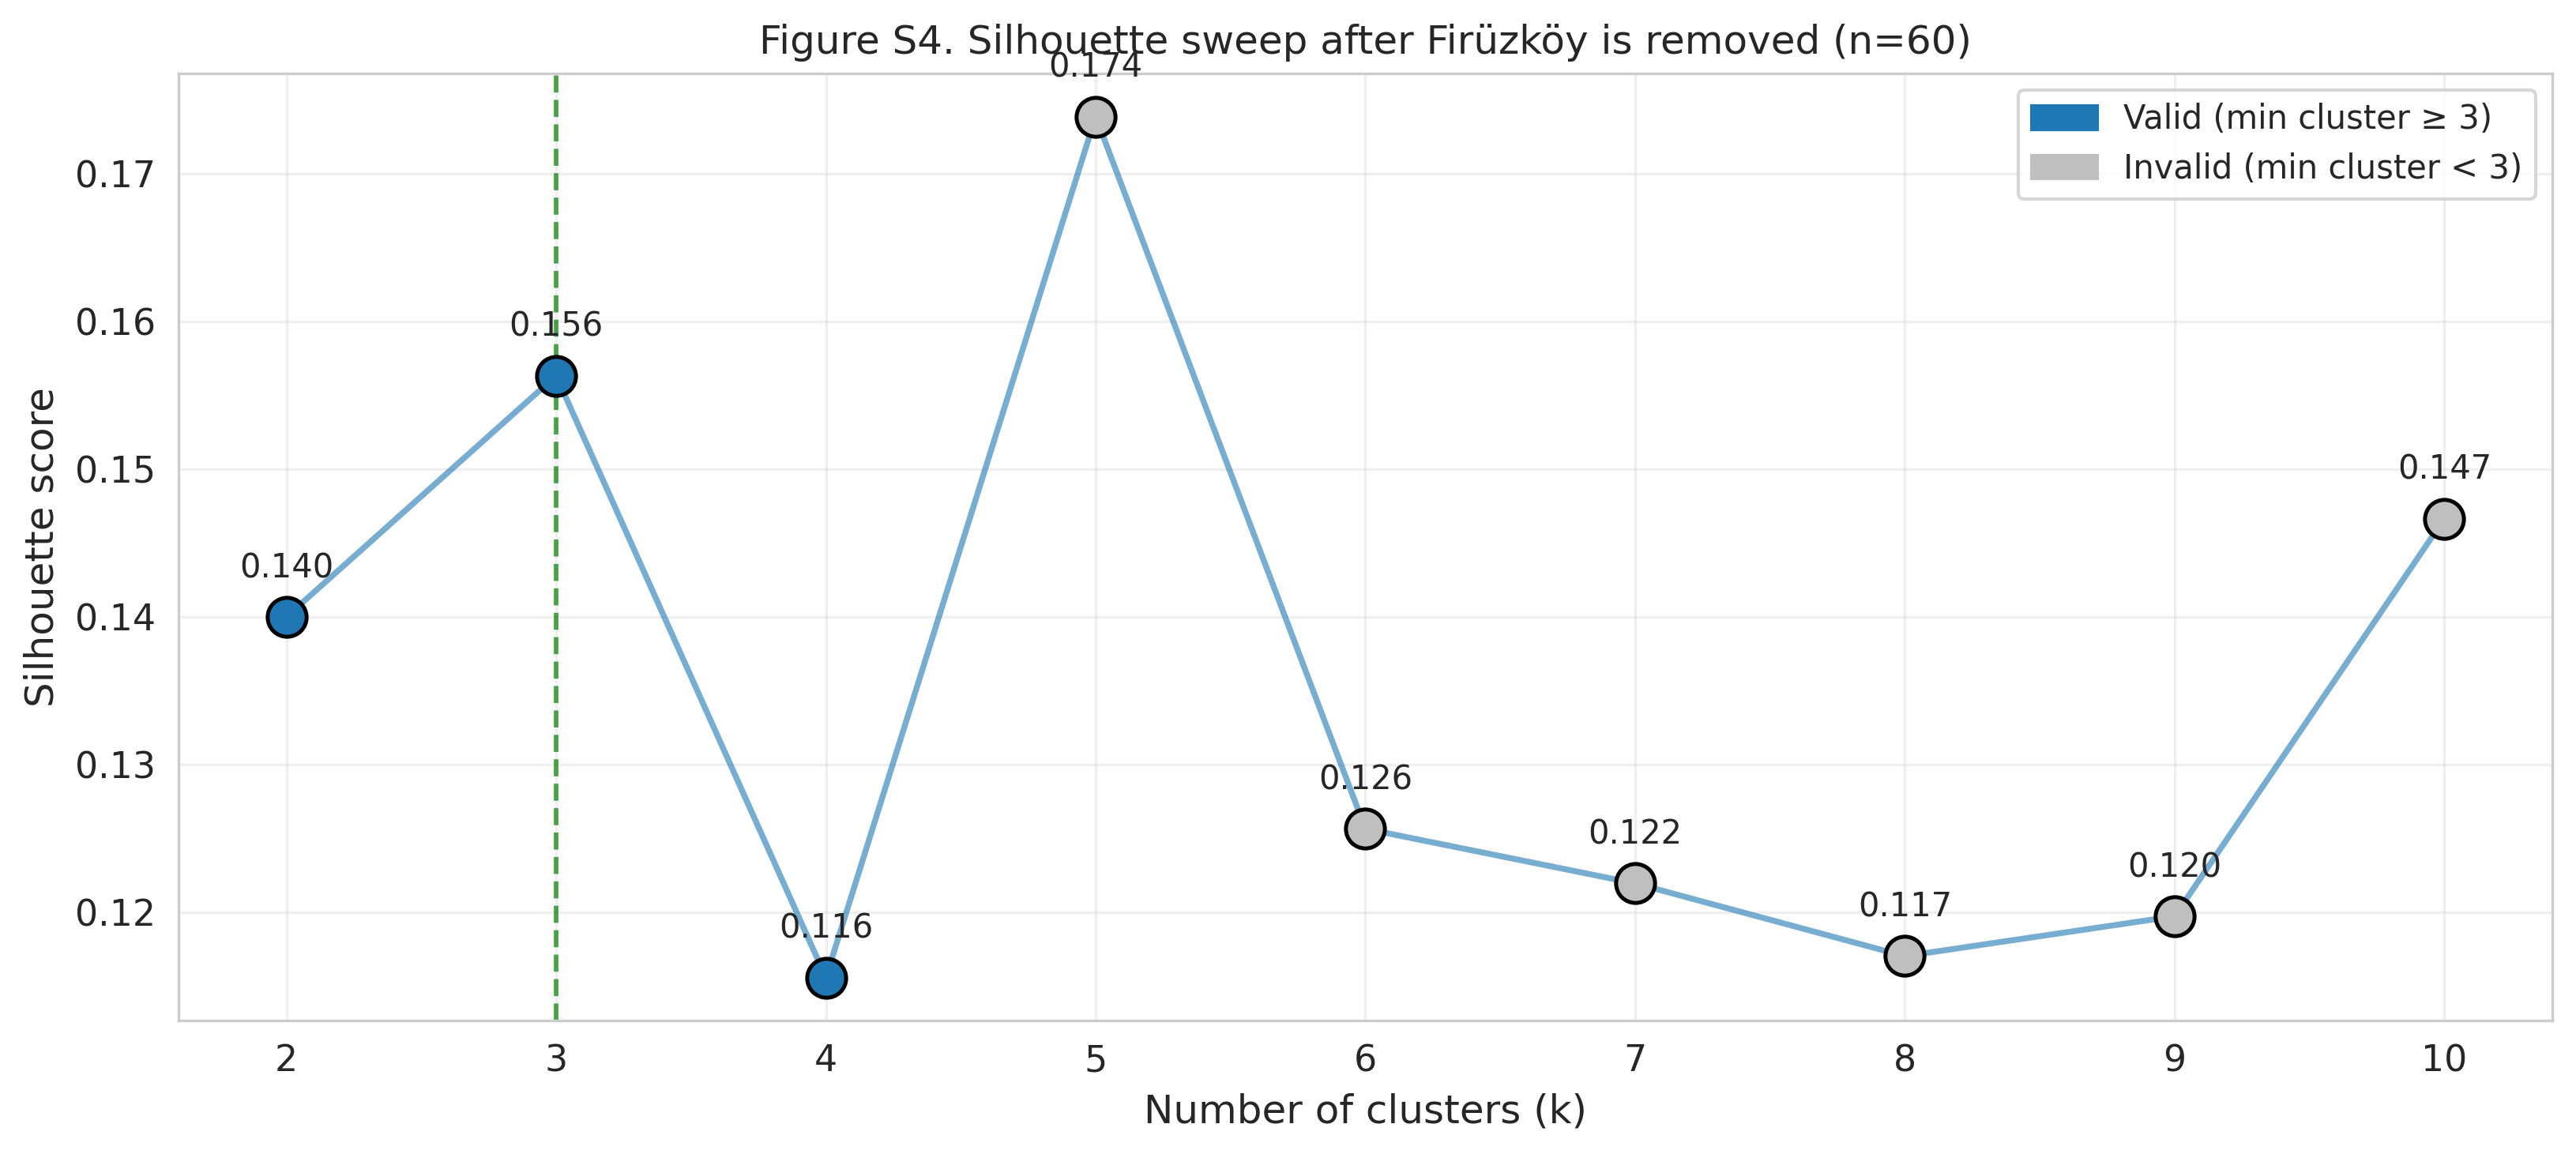

✓
[Figure S5] PCA 3-cat × Cluster ... 

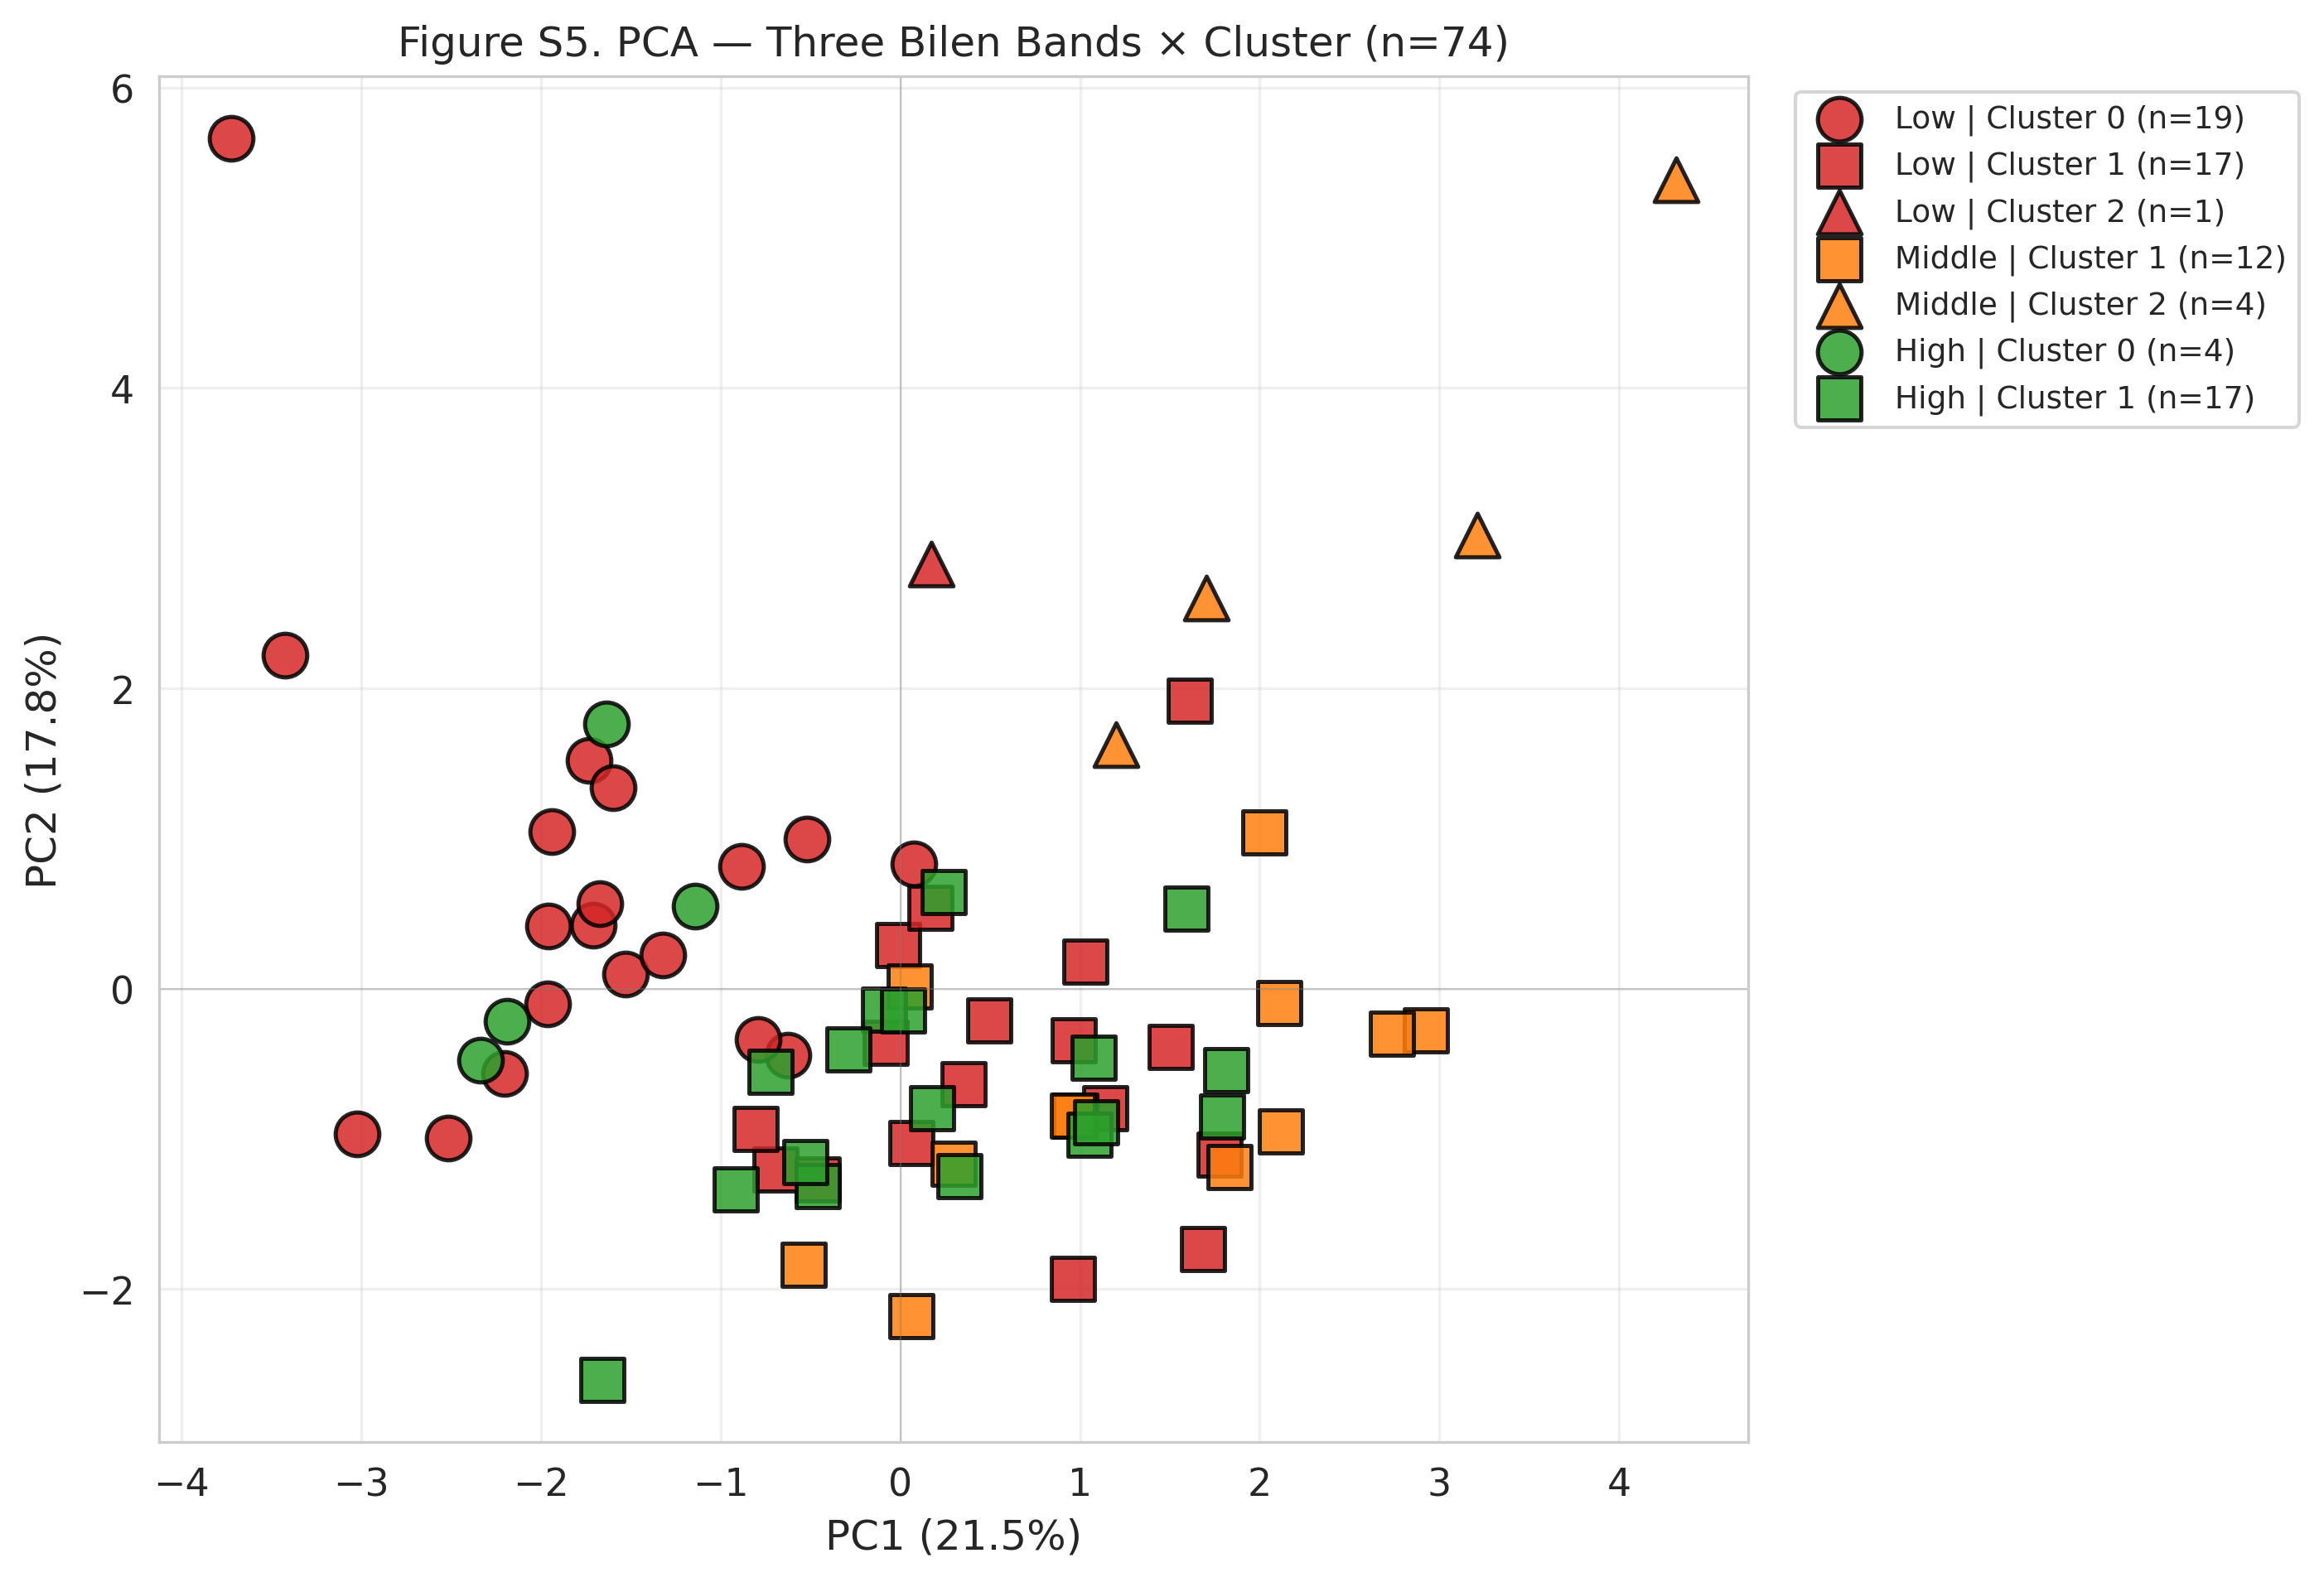

✓

██████████████████████████████████████████████████████████████████████
█  DONE — 19 files written to:
█  /content/manuscript_outputs
██████████████████████████████████████████████████████████████████████

   • Table2_descriptive_stats.xlsx
   • Figure3_silhouette_k2_k10.png
   • Figure4_cluster_centroids.png
   • Figure5_pca_safety_cluster.png
   • Figure6_cluster_3cat_distribution.png
   • Figure7_spearman.png
   • Figure8_ari_matrix.png
   • Figure9_consensus_matrix.png
   • TableS1_spearman.xlsx
   • TableS2_logistic.xlsx
   • TableS3_kruskal_fdr.xlsx
   • TableS4_sensitivity.xlsx
   • TableS5_QC_process.xlsx
   • TableS6_hdbscan_sweep.xlsx
   • TableS7_gmm_sweep.xlsx
   • TableS8_ari_matrix.xlsx
   • TableS9_hybrid_summary.xlsx
   • FigureS4_silhouette_no_firuzkoy.png
   • FigureS5_pca_3cat.png



In [1]:
# =============================================================================
# Istanbul as a Layered Gradient — Manuscript Output Pipeline
# =============================================================================
# Single-file reproducible script for Environment and Planning B submission.
# Generates ALL manuscript figures (Figure 3-9, S4, S5) and tables
# (Table 2, S1-S9) in one run.
#
# AUTHOR : Hasan Berkay COŞER (Istanbul Technical University)
# JOURNAL: Environment and Planning B: Urban Analytics and City Science
#
# USAGE
# -----
# A) Google Colab (no Drive needed):
#    1. Paste this file into a single cell.
#    2. Run the cell — a file upload prompt will open.
#    3. Upload your `all_street.xlsx` (or `all_street-3.xlsx`).
#    4. Outputs are written to `./manuscript_outputs/` inside the Colab session.
#       Download the folder when finished.
#
# B) Local machine (Python ≥ 3.9):
#    1. Edit the `DATA_PATH` variable below to point to your local xlsx.
#    2. Run `python this_file.py` (or run as a Jupyter cell).
#    3. Outputs land in `./manuscript_outputs/` next to the script.
#
# DEPENDENCIES
# ------------
# pandas, numpy, matplotlib, seaborn, scikit-learn, scipy, openpyxl
# hdbscan, statsmodels       (auto-installed if missing)
#
# OUTPUT (in ./manuscript_outputs/)
# ---------------------------------
#   Table2_descriptive_stats.xlsx
#   Figure3_silhouette_k2_k10.png        Figure4_cluster_centroids.png
#   Figure5_pca_safety_cluster.png       Figure6_cluster_3cat_distribution.png
#   Figure7_spearman.png                 Figure8_ari_matrix.png
#   Figure9_consensus_matrix.png         FigureS4_silhouette_no_firuzkoy.png
#   FigureS5_pca_3cat.png
#   TableS1_spearman.xlsx                TableS2_logistic.xlsx
#   TableS3_kruskal_fdr.xlsx             TableS4_sensitivity.xlsx
#   TableS5_QC_process.xlsx              TableS6_hdbscan_sweep.xlsx
#   TableS7_gmm_sweep.xlsx               TableS8_ari_matrix.xlsx
#   TableS9_hybrid_summary.xlsx
# =============================================================================

# =============================================================================
# 1. USER SETTINGS
# =============================================================================
# Set this to the LOCAL path of your all_street.xlsx file.
# Leave as None to use the Colab upload widget instead.
DATA_PATH = None                                # e.g. "/Users/you/all_street.xlsx"
OUTPUT_PATH = "./manuscript_outputs"
MANUAL_K = 3
MIN_PER_CLUSTER = 3

# =============================================================================
# 2. AUTO-INSTALL OPTIONAL DEPENDENCIES (hdbscan, statsmodels)
# =============================================================================
import subprocess, sys, importlib
def _ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_ensure("hdbscan")
_ensure("statsmodels")
_ensure("openpyxl")

# =============================================================================
# 3. IMPORTS
# =============================================================================
import os
import re
import unicodedata
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, log_loss, adjusted_rand_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr, chi2_contingency, kruskal
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist
from statsmodels.stats.multitest import multipletests
import hdbscan

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.size": 11, "font.family": "sans-serif", "figure.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
})
sns.set_style("whitegrid")

# =============================================================================
# 4. DATA DEFINITIONS — Bilen scores, neighbourhood→district, street→neighbourhood
# =============================================================================
BILEN_SCORES = {
    "Fevzi Çakmak-Pendik":    10.75, "Ziya Gökalp":            12.80,
    "Mareşal Çıkmazı":        13.06, "Hamidiye-Sultanbeyli":   14.02,
    "Fevzi Çakmak-Bağcılar":  14.07, "Cevizli":                14.10,
    "Ulus":                   14.36, "Kemal Paşa":             15.36,
    "Altınşehir":             15.75, "Fatih-Bağcılar":         15.86,
    "Barboros Hayrettinpaşa": 15.95, "Örnek":                  17.29,
    "Firüzköy":               17.55, "Teşvikiye":              19.60,
    "Slivrikapı":             20.20, "Meşrutiyet":             20.40,
    "Şehremini":              20.45, "Suadiye":                20.50,
    "Selami Ali":             20.50, "Mimar Sinan":            20.55,
    "Fenerbahçe":             20.60, "Gülsuyu":                20.80,
    "Atatürk-Ataşehir":       21.10, "Büyükdere":              21.20,
    "Bostancı":               21.25, "Salacak":                22.90,
    "Koşuyolu":               22.95,
}

MAHALLE_ILCE = {
    "Koşuyolu": "Üsküdar", "Bostancı": "Kadıköy", "Fenerbahçe": "Kadıköy",
    "Suadiye": "Kadıköy", "Salacak": "Üsküdar", "Mimar Sinan": "Üsküdar",
    "Selami Ali": "Üsküdar", "Büyükdere": "Sarıyer",
    "Atatürk-Ataşehir": "Ataşehir", "Gülsuyu": "Maltepe", "Slivrikapı": "Fatih",
    "Şehremini": "Fatih", "Meşrutiyet": "Şişli", "Teşvikiye": "Şişli",
    "Firüzköy": "Avcılar", "Fevzi Çakmak-Bağcılar": "Bağcılar",
    "Ulus": "Büyükçekmece", "Ziya Gökalp": "Başakşehir",
    "Mareşal Çıkmazı": "Güngören", "Barboros Hayrettinpaşa": "Gaziosmanpaşa",
    "Kemal Paşa": "Küçükçekmece", "Fevzi Çakmak-Pendik": "Pendik",
    "Cevizli": "Kartal", "Hamidiye-Sultanbeyli": "Sultanbeyli",
    "Altınşehir": "Başakşehir", "Fatih-Bağcılar": "Bağcılar",
    "Örnek": "Ataşehir",
}

SOKAK_MAHALLE = {
    # --- SAFE (37 streets) ---
    "KatipSalih_Street":               ("Koşuyolu", "Safe"),
    "YeniYol_Street":                  ("Bostancı", "Safe"),
    "Levent_Street":                   ("Bostancı", "Safe"),
    "DalyanAraligi_Street":            ("Fenerbahçe", "Safe"),
    "Bilgili_Street":                  ("Fenerbahçe", "Safe"),
    "AliFuatBasgil_Street":            ("Fenerbahçe", "Safe"),
    "VapurYolu_Street":                ("Suadiye", "Safe"),
    "SuadiyeCami_Street":              ("Suadiye", "Safe"),
    "NeyzenbasiHalilCan_Street":       ("Salacak", "Safe"),
    "Bestekar_SelahattinPinar_Street": ("Salacak", "Safe"),
    "IhsaniyeIskele_Street":           ("Salacak", "Safe"),
    "IsmailDumbullu_Street":           ("Mimar Sinan", "Safe"),
    "Durbali_Street":                  ("Mimar Sinan", "Safe"),
    "SairRuhi_Street":                 ("Mimar Sinan", "Safe"),
    "GumusArayici_Street":             ("Mimar Sinan", "Safe"),
    "Selanikliler_Street":             ("Selami Ali", "Safe"),
    "Secaat_Street":                   ("Selami Ali", "Safe"),
    "Uzumkizi_Street":                 ("Selami Ali", "Safe"),
    "Cami_Street":                     ("Büyükdere", "Safe"),
    "HancerliCavus_Street":            ("Büyükdere", "Safe"),
    "Cubukcu_Street":                  ("Büyükdere", "Safe"),
    "Seref_Street":                    ("Atatürk-Ataşehir", "Safe"),
    "Ekincioglu_Street":               ("Atatürk-Ataşehir", "Safe"),
    "Gulay_Street":                    ("Atatürk-Ataşehir", "Safe"),
    "Guleken_Street":                  ("Gülsuyu", "Safe"),
    "Sumer_Street":                    ("Gülsuyu", "Safe"),
    "IlkMektep_Street":                ("Slivrikapı", "Safe"),
    "YediSehitler_Street":             ("Slivrikapı", "Safe"),
    "Karakulak_Street":                ("Slivrikapı", "Safe"),
    "IbrahimCavus_Street":             ("Şehremini", "Safe"),
    "NecipAsim_Street":                ("Şehremini", "Safe"),
    "EbeKizi_Street":                  ("Meşrutiyet", "Safe"),
    "HrantDink_Street":                ("Meşrutiyet", "Safe"),
    "Akkirman_Street":                 ("Meşrutiyet", "Safe"),
    "Guzelbahce_Street":               ("Teşvikiye", "Safe"),
    "Av_SureyyaAgaoglu_Street":        ("Teşvikiye", "Safe"),
    "Poyracik_Street":                 ("Teşvikiye", "Safe"),
    # --- UNSAFE (37 streets) ---
    "Ahren_Street":        ("Firüzköy", "Unsafe"),
    "Aykutlu_Street":      ("Firüzköy", "Unsafe"),
    "Bakrac_Street":       ("Firüzköy", "Unsafe"),
    "Cagan_Street":        ("Firüzköy", "Unsafe"),
    "Duran_Street":        ("Firüzköy", "Unsafe"),
    "FiruzAga_Street":     ("Firüzköy", "Unsafe"),
    "Genc_Street":         ("Firüzköy", "Unsafe"),
    "HasanOnal_Street":    ("Firüzköy", "Unsafe"),
    "HirmiOnal_Street":    ("Firüzköy", "Unsafe"),
    "Koruturk_Street":     ("Firüzköy", "Unsafe"),
    "Onok_Street":         ("Firüzköy", "Unsafe"),
    "Siraevler_Street":    ("Firüzköy", "Unsafe"),
    "Tutun_Street":        ("Firüzköy", "Unsafe"),
    "Ulker_Street":        ("Firüzköy", "Unsafe"),
    "2052_Street":         ("Fevzi Çakmak-Bağcılar", "Unsafe"),
    "2058_Street":         ("Fevzi Çakmak-Bağcılar", "Unsafe"),
    "Isik_Street":         ("Ulus", "Unsafe"),
    "Menekse_Street":      ("Ulus", "Unsafe"),
    "Meydanalti_Street":   ("Ulus", "Unsafe"),
    "Tuna_Street":         ("Ziya Gökalp", "Unsafe"),
    "Kubilay_Street":      ("Mareşal Çıkmazı", "Unsafe"),
    "Birsel_Street":       ("Mareşal Çıkmazı", "Unsafe"),
    "1188_Street":         ("Barboros Hayrettinpaşa", "Unsafe"),
    "HalideEdip_Street":   ("Kemal Paşa", "Unsafe"),
    "Arda_Street":         ("Kemal Paşa", "Unsafe"),
    "Derya_Street":        ("Fevzi Çakmak-Pendik", "Unsafe"),
    "Duyar_Street":        ("Fevzi Çakmak-Pendik", "Unsafe"),
    "Kandira_Street":      ("Fevzi Çakmak-Pendik", "Unsafe"),
    "Kirlangic_Street":    ("Fevzi Çakmak-Pendik", "Unsafe"),
    "Mahir_Street":        ("Fevzi Çakmak-Pendik", "Unsafe"),
    "Ozlem_Street":        ("Fevzi Çakmak-Pendik", "Unsafe"),
    "Serkan_Street":       ("Fevzi Çakmak-Pendik", "Unsafe"),
    "GunCicegi_Street":    ("Cevizli", "Unsafe"),
    "Giresun_Street":      ("Cevizli", "Unsafe"),
    "Bulut_Street":        ("Hamidiye-Sultanbeyli", "Unsafe"),
    "Uzman_Street":        ("Hamidiye-Sultanbeyli", "Unsafe"),
    "Atilla_Street":       ("Hamidiye-Sultanbeyli", "Unsafe"),
}

# =============================================================================
# 5. HELPERS
# =============================================================================
def _normalize(s):
    """Turkish-character / whitespace / case insensitive normalization."""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode()
    s = re.sub(r"[\s_]+", "_", s)
    return s

_NORM_LOOKUP = {_normalize(k): k for k in SOKAK_MAHALLE}

def resolve_sokak(name):
    if name in SOKAK_MAHALLE:
        return name
    return _NORM_LOOKUP.get(_normalize(name))


# Manuscript-aligned Safety_3Cat (Low ≤17.55, Middle ≤20.50, High >20.50)
def safety_3cat(score):
    if pd.isna(score):
        return "Unknown"
    if score <= 17.55:
        return "Low"
    elif score <= 20.50:
        return "Middle"
    else:
        return "High"


def prepare_data(df_raw):
    """Match street rows to neighbourhood/district/safety/Bilen mappings."""
    if "Sokak" in df_raw.columns and "Street" not in df_raw.columns:
        df_raw = df_raw.rename(columns={"Sokak": "Street"})
    if "Street" not in df_raw.columns:
        raise KeyError(
            f"Excel must contain a 'Sokak' or 'Street' column. Found: {list(df_raw.columns)}"
        )

    df_raw["Street_Match"]    = df_raw["Street"].astype(str).str.strip()
    df_raw["Street_Resolved"] = df_raw["Street_Match"].map(resolve_sokak)
    matched = df_raw["Street_Resolved"].notna()
    df = df_raw[matched].copy()

    df["Mahalle"]      = df["Street_Resolved"].map(lambda x: SOKAK_MAHALLE[x][0])
    df["Safety_Label"] = df["Street_Resolved"].map(lambda x: SOKAK_MAHALLE[x][1])
    df["Ilce"]         = df["Mahalle"].map(MAHALLE_ILCE)
    df["Bilen_Score"]  = df["Mahalle"].map(BILEN_SCORES)
    df["Safety_3Cat"]  = df["Bilen_Score"].map(safety_3cat)

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    features = [c for c in numeric_cols
                if df[c].mean() >= 0.05 and c not in ["Bilen_Score", "Cluster"]]

    missing = df_raw[~matched]["Street"].tolist()
    print(f"✓ Matched streets : {len(df)} / {len(df_raw)}")
    print(f"✓ Feature count   : {len(features)}")
    print(f"✓ Safe={int((df['Safety_Label']=='Safe').sum())} | "
          f"Unsafe={int((df['Safety_Label']=='Unsafe').sum())}")
    print(f"✓ Low={int((df['Safety_3Cat']=='Low').sum())} | "
          f"Middle={int((df['Safety_3Cat']=='Middle').sum())} | "
          f"High={int((df['Safety_3Cat']=='High').sum())}")
    if missing:
        print(f"⚠ Unmatched ({len(missing)}): {missing}")
    return df, features


# =============================================================================
# 6. PLOTTING CONSTANTS (manuscript palette)
# =============================================================================
COLOR_SAFE   = "#2ca02c"
COLOR_UNSAFE = "#d62728"
COLOR_LOW    = "#d62728"
COLOR_MIDDLE = "#ff7f0e"
COLOR_HIGH   = "#2ca02c"
COLOR_BLUE   = "#1f77b4"
COLOR_GREY   = "#bfbfbf"
CLUSTER_MARKERS = ["o", "s", "^", "D", "P", "X"]


# =============================================================================
# 7. EXTENDED-ANALYSIS HELPERS (HDBSCAN sweep / GMM sweep / Ward)
# =============================================================================
def _hdbscan_sweep(X, mcs_range=range(3, 8)):
    results = []
    for mcs in mcs_range:
        labels = hdbscan.HDBSCAN(min_cluster_size=mcs, metric="euclidean").fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        noise_pct = n_noise / len(labels) * 100
        if n_clusters >= 2:
            mask = labels != -1
            sil = (silhouette_score(X[mask], labels[mask])
                   if mask.sum() > n_clusters else np.nan)
        else:
            sil = np.nan
        results.append({
            "min_cluster_size": mcs,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_pct": round(noise_pct, 1),
            "silhouette": round(sil, 4) if not np.isnan(sil) else np.nan,
        })
    df_res = pd.DataFrame(results)
    valid = df_res[df_res["n_clusters"] >= 2]
    if len(valid) > 0:
        best_mcs = int(df_res.loc[valid["noise_pct"].idxmin(), "min_cluster_size"])
        labels = hdbscan.HDBSCAN(min_cluster_size=best_mcs, metric="euclidean").fit_predict(X)
    else:
        labels = np.array([-1] * len(X)); best_mcs = None
    return labels, df_res, best_mcs


def _gmm_sweep(X, k_range=range(2, 8)):
    results = []
    for k in k_range:
        gmm = GaussianMixture(n_components=k, random_state=42, n_init=10).fit(X)
        probs = gmm.predict_proba(X); max_probs = probs.max(axis=1)
        results.append({
            "k": k,
            "BIC": round(gmm.bic(X), 2),
            "AIC": round(gmm.aic(X), 2),
            "avg_max_prob": round(max_probs.mean(), 4),
            "uncertain_pct": round((max_probs < 0.6).sum() / len(probs) * 100, 1),
        })
    df_res = pd.DataFrame(results)
    best_k = int(df_res.loc[df_res["BIC"].idxmin(), "k"])
    gmm = GaussianMixture(n_components=best_k, random_state=42, n_init=10).fit(X)
    return gmm.predict(X), df_res, best_k


def _hierarchical(X, method="ward", n_clusters=3):
    Z = linkage(X, method=method)
    coph_corr, _ = cophenet(Z, pdist(X))
    labels = AgglomerativeClustering(n_clusters=n_clusters, linkage=method).fit_predict(X)
    return labels, coph_corr


# =============================================================================
# 8. MASTER FUNCTION — generates ALL manuscript figures and tables
# =============================================================================
def generate_all_manuscript_outputs(df_raw, output_path=OUTPUT_PATH,
                                     min_per_cluster=MIN_PER_CLUSTER):
    print("\n" + "█" * 70)
    print("█  GENERATING ALL MANUSCRIPT OUTPUTS")
    print("█  Safety_3Cat thresholds: ≤17.55 (Low) / ≤20.50 (Middle) / >20.50 (High)")
    print("█" * 70)

    os.makedirs(output_path, exist_ok=True)
    print(f"\n✓ Output folder: {os.path.abspath(output_path)}")

    df, features = prepare_data(df_raw)
    s3 = df["Safety_3Cat"].value_counts()
    if all(s3.get(k, 0) == v for k, v in {"Low": 37, "Middle": 16, "High": 21}.items()):
        print("✓ Safety_3Cat distribution (37 / 16 / 21) matches manuscript Figure S5")

    X = StandardScaler().fit_transform(df[features])
    pca = PCA(n_components=2).fit(X)
    X_pca = pca.transform(X)
    pc1, pc2 = pca.explained_variance_ratio_ * 100
    print(f"✓ PCA: PC1 = {pc1:.1f}%, PC2 = {pc2:.1f}%")

    # K-means (k = MANUAL_K), then re-order clusters by ascending mean building share
    km = KMeans(n_clusters=MANUAL_K, n_init=20, random_state=42).fit(X)
    raw_labels = km.labels_
    df = df.copy()
    df["Cluster_raw"] = raw_labels
    order_map = {old: new for new, old in enumerate(
        df.groupby("Cluster_raw")["building"].mean().sort_values().index)}
    labels_ord = np.array([order_map[c] for c in raw_labels])
    df["Cluster"] = labels_ord
    print(f"✓ Cluster sizes (after re-ordering): "
          f"{[int((df['Cluster']==i).sum()) for i in range(MANUAL_K)]}")

    NBH = "Mahalle"
    written = []

    # -----------------------------------------------------------------
    # TABLE 2 — Descriptive statistics
    # -----------------------------------------------------------------
    print("\n[Table 2] Descriptive statistics ...", end=" ")
    tbl2 = df[features].agg(["mean", "std", "min", "max"]).T
    tbl2.columns = ["Mean (%)", "Std (%)", "Min (%)", "Max (%)"]
    tbl2 = tbl2.round(2)
    tbl2.loc["Total"] = [tbl2["Mean (%)"].sum(), "", "", ""]
    tbl2.index.name = "Feature"
    p = f"{output_path}/Table2_descriptive_stats.xlsx"
    tbl2.to_excel(p); written.append(p); print("✓")

    # -----------------------------------------------------------------
    # FIGURE 3 — Silhouette k = 2..10
    # -----------------------------------------------------------------
    print("[Figure 3] Silhouette k=2..10 ...", end=" ")
    scores = {}; min_sizes = {}
    for k in range(2, 11):
        kmk = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
        scores[k] = silhouette_score(X, kmk.labels_)
        min_sizes[k] = int(np.bincount(kmk.labels_).min())
    fig, ax = plt.subplots(figsize=(11, 5))
    ks = sorted(scores.keys()); vals = [scores[k] for k in ks]
    pt_colors = [COLOR_BLUE if min_sizes[k] >= min_per_cluster else COLOR_GREY for k in ks]
    ax.plot(ks, vals, "-", lw=1.8, color=COLOR_BLUE, alpha=0.6, zorder=2)
    for k, v, c in zip(ks, vals, pt_colors):
        ax.scatter(k, v, s=140, c=c, edgecolors="black", linewidths=1.2, zorder=3)
        ax.annotate(f"{v:.3f}", (k, v), textcoords="offset points",
                    xytext=(0, 12), ha="center", fontsize=10)
    valid = {k: v for k, v in scores.items() if min_sizes[k] >= min_per_cluster}
    best_k = max(valid, key=valid.get)
    ax.axvline(best_k, color="green", ls="--", lw=1.4, alpha=0.7)
    ax.legend(handles=[
        mpatches.Patch(color=COLOR_BLUE, label="Valid (min cluster ≥ 3)"),
        mpatches.Patch(color=COLOR_GREY, label="Invalid (min cluster < 3)"),
        plt.Line2D([0],[0], color="green", ls="--", label=f"Selected k = {best_k}"),
    ], loc="upper right", fontsize=10)
    ax.set_xlabel("Number of clusters (k)", fontsize=12)
    ax.set_ylabel("Silhouette score", fontsize=12)
    ax.set_title("Figure 3. Silhouette scores from k=2 to k=10", fontsize=12)
    ax.set_xticks(ks); ax.grid(alpha=0.3); plt.tight_layout()
    p = f"{output_path}/Figure3_silhouette_k2_k10.png"
    plt.savefig(p, dpi=300, bbox_inches="tight"); plt.show(); plt.close()
    written.append(p); print("✓")

    # -----------------------------------------------------------------
    # FIGURE 4 — Cluster centroids heatmap
    # -----------------------------------------------------------------
    print("[Figure 4] Cluster centroids ...", end=" ")
    means = df.groupby("Cluster")[features].mean().T
    fig, ax = plt.subplots(figsize=(7.5, max(5, 0.42 * len(features))))
    sns.heatmap(means, annot=True, fmt=".2f", cmap="coolwarm",
                center=means.values.mean(), ax=ax,
                cbar_kws={"label": "Mean (%)"}, linewidths=0.4,
                linecolor="white", annot_kws={"fontsize": 10})
    ax.set_title("Figure 4. Mean pixel composition of the three clusters", fontsize=12)
    ax.set_xlabel("Cluster (ordered by ascending mean building share)", fontsize=11)
    plt.tight_layout()
    p = f"{output_path}/Figure4_cluster_centroids.png"
    plt.savefig(p, dpi=300, bbox_inches="tight"); plt.show(); plt.close()
    written.append(p); print("✓")

    # -----------------------------------------------------------------
    # FIGURE 5 — PCA Safe/Unsafe × Cluster
    # -----------------------------------------------------------------
    print("[Figure 5] PCA Safe/Unsafe × Cluster ...", end=" ")
    fig, ax = plt.subplots(figsize=(9.5, 6.5))
    cols = {"Safe": COLOR_SAFE, "Unsafe": COLOR_UNSAFE}
    for cat in ["Safe", "Unsafe"]:
        for c in range(MANUAL_K):
            mask = (df["Safety_Label"] == cat) & (df["Cluster"] == c)
            if mask.sum():
                ax.scatter(X_pca[mask.values, 0], X_pca[mask.values, 1],
                           c=cols[cat], marker=CLUSTER_MARKERS[c], s=160,
                           edgecolors="black", linewidths=1.2, alpha=0.85,
                           label=f"{cat} | Cluster {c} (n={int(mask.sum())})")
    ax.set_xlabel(f"PC1 ({pc1:.1f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({pc2:.1f}%)", fontsize=12)
    ax.set_title("Figure 5. Streets in the PCA plane by safety label and cluster", fontsize=12)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    ax.grid(alpha=0.3); ax.axhline(0, color="gray", lw=0.5, alpha=0.4)
    ax.axvline(0, color="gray", lw=0.5, alpha=0.4); plt.tight_layout()
    p = f"{output_path}/Figure5_pca_safety_cluster.png"
    plt.savefig(p, dpi=300, bbox_inches="tight"); plt.show(); plt.close()
    written.append(p); print("✓")

    # -----------------------------------------------------------------
    # FIGURE 6 — Cluster × 3-band safety distribution
    # -----------------------------------------------------------------
    print("[Figure 6] Cluster × 3-band safety ...", end=" ")
    ct3 = pd.crosstab(df["Safety_3Cat"], df["Cluster"]).reindex(
        ["Low", "Middle", "High"], fill_value=0)
    ct3_T = ct3.T
    fig, ax = plt.subplots(figsize=(9, 5))
    ct3_T.plot(kind="bar", stacked=False, ax=ax,
               color=[COLOR_LOW, COLOR_MIDDLE, COLOR_HIGH],
               edgecolor="black", width=0.75)
    ax.set_title("Figure 6. Cluster × three-band Bilen safety score (n=74)", fontsize=12)
    ax.set_ylabel("Number of streets", fontsize=11)
    ax.set_xlabel("Cluster", fontsize=11)
    ax.legend(title="Bilen band", loc="upper right")
    ax.set_xticklabels([f"Cluster {i}" for i in ct3_T.index], rotation=0)
    plt.tight_layout()
    p = f"{output_path}/Figure6_cluster_3cat_distribution.png"
    plt.savefig(p, dpi=300, bbox_inches="tight"); plt.show(); plt.close()
    written.append(p); print(f"✓ (Cluster 0: {ct3_T.iloc[0].to_dict()})")

    # -----------------------------------------------------------------
    # FIGURE 7 — Spearman (positive = green, negative = red)
    # -----------------------------------------------------------------
    print("[Figure 7] Spearman correlations ...", end=" ")
    nbh_df = df.groupby([NBH, "Bilen_Score"])[features].mean().reset_index()
    records = []
    for feat in features:
        r, p_val = spearmanr(nbh_df[feat], nbh_df["Bilen_Score"])
        records.append({"Feature": feat, "r": r, "p": p_val})
    sp_df = pd.DataFrame(records).sort_values("r")
    fig, ax = plt.subplots(figsize=(9, max(5, 0.4 * len(sp_df))))
    bar_colors = [COLOR_SAFE if r >= 0 else COLOR_UNSAFE for r in sp_df["r"]]
    ax.barh(sp_df["Feature"], sp_df["r"], color=bar_colors,
            edgecolor="black", linewidth=0.6)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Spearman r", fontsize=12)
    ax.set_title(
        f"Figure 7. Spearman correlation with Bilen Score (neighborhood level, n={len(nbh_df)})",
        fontsize=11)
    ax.grid(axis="x", alpha=0.3); plt.tight_layout()
    p = f"{output_path}/Figure7_spearman.png"
    plt.savefig(p, dpi=300, bbox_inches="tight"); plt.show(); plt.close()
    written.append(p); print("✓")

    # -----------------------------------------------------------------
    # EXTENDED ANALYSIS for Figure 8 + supplementary tables
    # -----------------------------------------------------------------
    print("\n--- Extended analysis (for Figure 8 + Tables S6/S7/S8/S9) ---")
    print("[HDBSCAN] sweep mcs 3..7 ...", end=" ")
    hdb_labels, hdb_summary, hdb_best_mcs = _hdbscan_sweep(X)
    print(f"✓ (best mcs={hdb_best_mcs}, noise={hdb_summary['noise_pct'].min()}%)")
    print("[GMM] sweep k 2..7 by BIC ...", end=" ")
    gmm_labels, gmm_summary, gmm_best_k = _gmm_sweep(X)
    print(f"✓ (best k={gmm_best_k})")
    print("[Hierarchical] Ward, k=3 ...", end=" ")
    hier_labels, coph_corr = _hierarchical(X)
    print(f"✓ (cophenetic={coph_corr:.3f})")

    # -----------------------------------------------------------------
    # FIGURE 8 — ARI matrix
    # -----------------------------------------------------------------
    print("[Figure 8] ARI matrix ...", end=" ")
    methods = {"K-means": raw_labels, "HDBSCAN": hdb_labels,
               "GMM": gmm_labels, "Hierarchical": hier_labels}
    names = list(methods.keys())
    ari_matrix = pd.DataFrame(
        [[adjusted_rand_score(methods[a], methods[b]) for b in names] for a in names],
        index=names, columns=names)
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    sns.heatmap(ari_matrix, annot=True, fmt=".3f", cmap="RdYlGn",
                xticklabels=names, yticklabels=names, vmin=0, vmax=1, ax=ax,
                cbar_kws={"label": "Adjusted Rand Index"},
                linewidths=0.5, square=True,
                annot_kws={"fontsize": 11, "fontweight": "bold"})
    ax.set_title(f"Figure 8. Cross-Method Agreement (ARI) — MAIN (n={len(X)})", fontsize=12)
    plt.tight_layout()
    p = f"{output_path}/Figure8_ari_matrix.png"
    plt.savefig(p, dpi=300, bbox_inches="tight"); plt.show(); plt.close()
    written.append(p); print("✓")

    # -----------------------------------------------------------------
    # FIGURE 9 — Consensus matrix (1000 bootstraps)
    # -----------------------------------------------------------------
    print("[Figure 9] Consensus matrix (1000 bootstraps) ...", end=" ", flush=True)
    n = len(X)
    co_assoc = np.zeros((n, n)); co_count = np.zeros((n, n))
    rng = np.random.default_rng(0)
    for b in range(1000):
        idx = rng.choice(n, size=n, replace=True)
        u_idx = np.unique(idx)
        if len(u_idx) < 3: continue
        try:
            lab_b = KMeans(n_clusters=3, n_init=5, random_state=b).fit_predict(X[u_idx])
        except Exception:
            continue
        idx_to_lab = dict(zip(u_idx, lab_b))
        for i in u_idx:
            for j in u_idx:
                co_count[i, j] += 1
                if idx_to_lab[i] == idx_to_lab[j]:
                    co_assoc[i, j] += 1
    with np.errstate(invalid="ignore", divide="ignore"):
        consensus = np.where(co_count > 0, co_assoc / co_count, 0)
    order = np.argsort(labels_ord)
    consensus_ord = consensus[np.ix_(order, order)]
    fig, ax = plt.subplots(figsize=(8.5, 7.5))
    im = ax.imshow(consensus_ord, cmap="rocket_r", vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, label="Co-assignment rate")
    ax.set_title(f"Figure 9. Consensus Matrix (n={n}, k=3, 1000 bootstraps)\n"
                 "Streets ordered by cluster assignment", fontsize=12)
    ax.set_xlabel("Street index (ordered)", fontsize=11)
    ax.set_ylabel("Street index (ordered)", fontsize=11)
    plt.tight_layout()
    p = f"{output_path}/Figure9_consensus_matrix.png"
    plt.savefig(p, dpi=300, bbox_inches="tight"); plt.show(); plt.close()
    written.append(p); print("✓")

    # -----------------------------------------------------------------
    # TABLE S1 — Spearman
    # -----------------------------------------------------------------
    print("[Table S1] Spearman ...", end=" ")
    tblS1 = sp_df.copy()
    tblS1["r"] = tblS1["r"].apply(lambda x: f"{x:+.3f}")
    tblS1["p"] = tblS1["p"].round(3)
    tblS1 = tblS1[["Feature", "r", "p"]].sort_values("r", ascending=False)
    p = f"{output_path}/TableS1_spearman.xlsx"
    tblS1.to_excel(p, index=False); written.append(p); print("✓")

    # -----------------------------------------------------------------
    # TABLE S2 — Logistic regression (street-level, C=1.0)
    # -----------------------------------------------------------------
    print("[Table S2] Logistic regression ...", end=" ")
    y_bin = (df["Safety_Label"] == "Safe").astype(int).values
    Xs = StandardScaler().fit_transform(df[features])
    lr = LogisticRegression(max_iter=2000, C=1.0, random_state=42).fit(Xs, y_bin)
    y_prob = lr.predict_proba(Xs)
    ll_full = -log_loss(y_bin, y_prob, normalize=False)
    p_null = y_bin.mean()
    ll_null = np.sum(y_bin * np.log(p_null) + (1 - y_bin) * np.log(1 - p_null))
    n_l = len(y_bin)
    mcfadden = 1 - (ll_full / ll_null)
    cox_snell = 1 - np.exp((2 / n_l) * (ll_null - ll_full))
    nagelkerke = cox_snell / (1 - np.exp((2 / n_l) * ll_null))
    acc = (lr.predict(Xs) == y_bin).mean()
    tblS2 = pd.DataFrame({
        "Metric": ["n", "Training accuracy", "McFadden R²", "Cox-Snell R²", "Nagelkerke R²"],
        "Value":  [n_l, round(acc, 3), round(mcfadden, 3),
                   round(cox_snell, 3), round(nagelkerke, 3)],
    })
    coef_df = pd.DataFrame({
        "Feature": features,
        "Coefficient (standardised)": lr.coef_[0].round(3),
        "Odds ratio": np.exp(lr.coef_[0]).round(3),
    }).sort_values("Coefficient (standardised)", ascending=False)
    p = f"{output_path}/TableS2_logistic.xlsx"
    with pd.ExcelWriter(p) as w:
        tblS2.to_excel(w, sheet_name="summary", index=False)
        coef_df.to_excel(w, sheet_name="coefficients", index=False)
    written.append(p); print(f"✓ (acc={acc:.3f}, McFadden={mcfadden:.3f})")

    # -----------------------------------------------------------------
    # TABLE S3 — Kruskal-Wallis + FDR
    # -----------------------------------------------------------------
    print("[Table S3] Kruskal-Wallis + FDR ...", end=" ")
    kw_records = []
    for feat in features:
        groups = [df[df["Safety_3Cat"] == c][feat].values
                  for c in ["Low", "Middle", "High"]
                  if c in df["Safety_3Cat"].values]
        if len(groups) >= 2:
            H, p_val = kruskal(*groups)
            kw_records.append({"Feature": feat, "H": round(H, 2), "p (raw)": p_val})
    kw_df = pd.DataFrame(kw_records).sort_values("p (raw)")
    rej, p_fdr, _, _ = multipletests(kw_df["p (raw)"].values, method="fdr_bh")
    kw_df["p (FDR)"] = np.round(p_fdr, 4)
    kw_df["Significant"] = ["Yes" if r else "No" for r in rej]
    kw_df["p (raw)"] = kw_df["p (raw)"].round(4)
    p = f"{output_path}/TableS3_kruskal_fdr.xlsx"
    kw_df.to_excel(p, index=False); written.append(p)
    print(f"✓ ({rej.sum()}/{len(kw_df)} significant)")

    # -----------------------------------------------------------------
    # TABLE S4 — Sensitivity (Firüzköy excluded), with HDBSCAN noise %,
    #             Mean ARI, and bootstrap stability ≥0.80
    # -----------------------------------------------------------------
    print("[Table S4] Sensitivity (Firüzköy excluded) ...", end=" ")
    df_s = df[df[NBH] != "Firüzköy"].reset_index(drop=True)
    X_s = StandardScaler().fit_transform(df_s[features])
    km_s = KMeans(n_clusters=3, n_init=20, random_state=42).fit(X_s)
    sil_s = silhouette_score(X_s, km_s.labels_)
    sil_main = silhouette_score(X, labels_ord)

    # Chi-square + Bergsma (2013) bias-corrected Cramér's V
    def _bcV(ct_vals):
        chi2, p_val, _, _ = chi2_contingency(ct_vals)
        n = ct_vals.sum(); r, c = ct_vals.shape
        phi2 = chi2 / n
        phi2_corr = max(0, phi2 - ((r - 1) * (c - 1)) / (n - 1))
        r_corr = r - (r - 1) ** 2 / (n - 1)
        c_corr = c - (c - 1) ** 2 / (n - 1)
        denom = min(r_corr - 1, c_corr - 1)
        V = np.sqrt(phi2_corr / denom) if denom > 0 else np.nan
        return chi2, p_val, V

    ct_main = pd.crosstab(labels_ord, df["Safety_Label"]).values
    chi2_main, p_main, V_main = _bcV(ct_main)
    ct_s = pd.crosstab(km_s.labels_, df_s["Safety_Label"]).values
    chi2_s, p_s, V_s = _bcV(ct_s)

    coph_main = cophenet(linkage(X, method="ward"), pdist(X))[0]
    coph_sens = cophenet(linkage(X_s, method="ward"), pdist(X_s))[0]

    # HDBSCAN noise %
    hdb_noise_main = hdb_summary["noise_pct"].min()
    hdb_s_labels = hdbscan.HDBSCAN(min_cluster_size=3, metric="euclidean").fit_predict(X_s)
    hdb_noise_s = round((hdb_s_labels == -1).sum() / len(hdb_s_labels) * 100, 1)

    # Mean ARI
    mean_ari_main = round(ari_matrix.values[np.triu_indices(len(names), k=1)].mean(), 3)
    methods_s = {
        "K-means":      km_s.labels_,
        "Hierarchical": AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_s),
        "GMM":          GaussianMixture(n_components=gmm_best_k, random_state=42,
                                        n_init=10).fit_predict(X_s),
    }
    ns_s = list(methods_s.keys())
    ari_s = np.array([[adjusted_rand_score(methods_s[a], methods_s[b])
                        for b in ns_s] for a in ns_s])
    mean_ari_s = round(ari_s[np.triu_indices(len(ns_s), k=1)].mean(), 3)

    # Bootstrap stability ≥0.80 (main: re-use consensus)
    mask_m = np.triu(np.ones((n, n), dtype=bool), k=1)
    total_m = int(mask_m.sum()); stable_m = int((consensus[mask_m] >= 0.80).sum())
    boot_main = f"{stable_m} / {total_m} ({stable_m / total_m * 100:.1f}%)"

    # Bootstrap stability ≥0.80 (sensitivity)
    n_s_len = len(X_s)
    co_a = np.zeros((n_s_len, n_s_len)); co_c = np.zeros((n_s_len, n_s_len))
    rng_s = np.random.default_rng(0)
    for b in range(1000):
        idx_s = rng_s.choice(n_s_len, size=n_s_len, replace=True)
        u = np.unique(idx_s)
        if len(u) < 3: continue
        try:
            lab = KMeans(n_clusters=3, n_init=5, random_state=b).fit_predict(X_s[u])
        except Exception:
            continue
        d = dict(zip(u, lab))
        for i in u:
            for j in u:
                co_c[i, j] += 1
                if d[i] == d[j]:
                    co_a[i, j] += 1
    with np.errstate(invalid="ignore", divide="ignore"):
        cons_s = np.where(co_c > 0, co_a / co_c, 0)
    mask_s = np.triu(np.ones((n_s_len, n_s_len), dtype=bool), k=1)
    total_s = int(mask_s.sum()); stable_s = int((cons_s[mask_s] >= 0.80).sum())
    boot_sens = f"{stable_s} / {total_s} ({stable_s / total_s * 100:.1f}%)"

    def _fchi(c, pv): return f"{c:.2f} (p{'<0.001' if pv < 0.001 else f'={pv:.3f}'})"

    tblS4 = pd.DataFrame({
        "Metric": ["Selected k", "Silhouette", "χ² (Cluster × Safety)",
                   "Bias-corrected V", "Cophenetic correlation",
                   "HDBSCAN noise %", "Mean ARI", "Bootstrap stability ≥0.80"],
        "Main (n=74)":        [3, round(sil_main, 3), _fchi(chi2_main, p_main),
                                round(V_main, 3), round(coph_main, 3),
                                hdb_noise_main, mean_ari_main, boot_main],
        "Sensitivity (n=60)": [3, round(sil_s, 3), _fchi(chi2_s, p_s),
                                round(V_s, 3), round(coph_sens, 3),
                                hdb_noise_s, mean_ari_s, boot_sens],
    })
    p = f"{output_path}/TableS4_sensitivity.xlsx"
    tblS4.to_excel(p, index=False); written.append(p)
    print(f"✓ (main boot={boot_main}, sens boot={boot_sens})")

    # -----------------------------------------------------------------
    # TABLE S5 — QC process
    # -----------------------------------------------------------------
    print("[Table S5] QC process ...", end=" ")
    tblS5 = pd.DataFrame({
        "Stage": ["1. Image collection", "2. Image selection", "3. Segmentation",
                  "4. Visual review", "5. First-pass acceptance",
                  "6. Most common removal reason", "7. Correction procedure",
                  "8. Final dataset"],
        "Description": [
            "74 streets × 12 points × 360° panorama (Google Street View Static API)",
            "From each point, angle toward the facade across the middle of the street",
            "Cityscapes pre-trained DeepLabV3 (ResNet-101)",
            "Each segmentation output inspected manually",
            "Over 80% of images of acceptable quality",
            "Road pixels misclassified as pavement (systematic on cobblestone surfaces)",
            "Re-capture and re-segmentation from an alternative point for dropped streets",
            "One clean representative segmentation output per street (n=74)",
        ],
    })
    p = f"{output_path}/TableS5_QC_process.xlsx"
    tblS5.to_excel(p, index=False); written.append(p); print("✓")

    # -----------------------------------------------------------------
    # TABLE S6 — HDBSCAN sweep
    # -----------------------------------------------------------------
    print("[Table S6] HDBSCAN sweep ...", end=" ")
    p = f"{output_path}/TableS6_hdbscan_sweep.xlsx"
    hdb_summary.to_excel(p, index=False); written.append(p); print("✓")

    # -----------------------------------------------------------------
    # TABLE S7 — GMM sweep
    # -----------------------------------------------------------------
    print("[Table S7] GMM sweep ...", end=" ")
    p = f"{output_path}/TableS7_gmm_sweep.xlsx"
    gmm_summary.to_excel(p, index=False); written.append(p); print("✓")

    # -----------------------------------------------------------------
    # TABLE S8 — ARI matrix
    # -----------------------------------------------------------------
    print("[Table S8] ARI matrix ...", end=" ")
    p = f"{output_path}/TableS8_ari_matrix.xlsx"
    ari_matrix.round(3).to_excel(p); written.append(p); print("✓")

    # -----------------------------------------------------------------
    # TABLE S9 — Hybrid-fabric summary
    # -----------------------------------------------------------------
    print("[Table S9] Hybrid-fabric summary ...", end=" ")
    mean_ari = ari_matrix.values[np.triu_indices(len(names), k=1)].mean()
    hdb_min_noise = hdb_summary["noise_pct"].min()
    gmm_min_uncert = gmm_summary["uncertain_pct"].min()
    tblS9 = pd.DataFrame({
        "Evidence": [
            "K-means silhouette (k=3)",
            "HDBSCAN minimum noise %",
            "GMM lowest uncertainty %",
            "Cophenetic correlation (Ward)",
            "Mean pairwise ARI across methods",
        ],
        "Value": [round(sil_main, 3), hdb_min_noise, gmm_min_uncert,
                  round(coph_corr, 3), round(mean_ari, 3)],
        "Threshold for strong structure": ["> 0.50", "< 10 %", "< 10 %",
                                           "> 0.60", "> 0.50"],
        "Interpretation": [
            "Weak" if sil_main < 0.50 else "Strong",
            "Hybrid" if hdb_min_noise > 10 else "Clean",
            "Hybrid" if gmm_min_uncert > 10 else "Clean",
            "Weak" if coph_corr < 0.60 else "Strong",
            "Hybrid" if mean_ari < 0.50 else "Stable",
        ],
    })
    p = f"{output_path}/TableS9_hybrid_summary.xlsx"
    tblS9.to_excel(p, index=False); written.append(p); print("✓")

    # -----------------------------------------------------------------
    # FIGURE S4 — Silhouette without Firüzköy
    # -----------------------------------------------------------------
    print("[Figure S4] Silhouette without Firüzköy ...", end=" ")
    scores_s = {}; min_sizes_s = {}
    for k in range(2, 11):
        kmk = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_s)
        scores_s[k] = silhouette_score(X_s, kmk.labels_)
        min_sizes_s[k] = int(np.bincount(kmk.labels_).min())
    fig, ax = plt.subplots(figsize=(11, 5))
    ks = sorted(scores_s.keys()); vals = [scores_s[k] for k in ks]
    pt_colors = [COLOR_BLUE if min_sizes_s[k] >= min_per_cluster else COLOR_GREY for k in ks]
    ax.plot(ks, vals, "-", lw=1.8, color=COLOR_BLUE, alpha=0.6, zorder=2)
    for k, v, c in zip(ks, vals, pt_colors):
        ax.scatter(k, v, s=140, c=c, edgecolors="black", linewidths=1.2, zorder=3)
        ax.annotate(f"{v:.3f}", (k, v), textcoords="offset points",
                    xytext=(0, 12), ha="center", fontsize=10)
    valid_s = {k: v for k, v in scores_s.items() if min_sizes_s[k] >= min_per_cluster}
    if valid_s:
        ax.axvline(max(valid_s, key=valid_s.get), color="green", ls="--", lw=1.4, alpha=0.7)
    ax.legend(handles=[
        mpatches.Patch(color=COLOR_BLUE, label="Valid (min cluster ≥ 3)"),
        mpatches.Patch(color=COLOR_GREY, label="Invalid (min cluster < 3)"),
    ], loc="upper right", fontsize=10)
    ax.set_xlabel("Number of clusters (k)", fontsize=12)
    ax.set_ylabel("Silhouette score", fontsize=12)
    ax.set_title("Figure S4. Silhouette sweep after Firüzköy is removed (n=60)", fontsize=12)
    ax.set_xticks(ks); ax.grid(alpha=0.3); plt.tight_layout()
    p = f"{output_path}/FigureS4_silhouette_no_firuzkoy.png"
    plt.savefig(p, dpi=300, bbox_inches="tight"); plt.show(); plt.close()
    written.append(p); print("✓")

    # -----------------------------------------------------------------
    # FIGURE S5 — PCA 3-cat × Cluster
    # -----------------------------------------------------------------
    print("[Figure S5] PCA 3-cat × Cluster ...", end=" ")
    fig, ax = plt.subplots(figsize=(9.5, 6.5))
    cols3 = {"Low": COLOR_LOW, "Middle": COLOR_MIDDLE, "High": COLOR_HIGH}
    for cat in ["Low", "Middle", "High"]:
        for c in range(MANUAL_K):
            mask = (df["Safety_3Cat"] == cat) & (df["Cluster"] == c)
            if mask.sum():
                ax.scatter(X_pca[mask.values, 0], X_pca[mask.values, 1],
                           c=cols3[cat], marker=CLUSTER_MARKERS[c], s=160,
                           edgecolors="black", linewidths=1.2, alpha=0.85,
                           label=f"{cat} | Cluster {c} (n={int(mask.sum())})")
    ax.set_xlabel(f"PC1 ({pc1:.1f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({pc2:.1f}%)", fontsize=12)
    ax.set_title(f"Figure S5. PCA — Three Bilen Bands × Cluster (n={len(X)})", fontsize=12)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    ax.grid(alpha=0.3); ax.axhline(0, color="gray", lw=0.5, alpha=0.4)
    ax.axvline(0, color="gray", lw=0.5, alpha=0.4); plt.tight_layout()
    p = f"{output_path}/FigureS5_pca_3cat.png"
    plt.savefig(p, dpi=300, bbox_inches="tight"); plt.show(); plt.close()
    written.append(p); print("✓")

    # -----------------------------------------------------------------
    # SUMMARY
    # -----------------------------------------------------------------
    print("\n" + "█" * 70)
    print(f"█  DONE — {len(written)} files written to:")
    print(f"█  {os.path.abspath(output_path)}")
    print("█" * 70 + "\n")
    for f in written:
        print(f"   • {os.path.basename(f)}")
    print()
    return {"df": df, "labels": labels_ord, "features": features,
            "X_pca": X_pca, "output_path": output_path, "files": written}


# =============================================================================
# 9. DATA LOADING — local path OR Colab upload widget
# =============================================================================
def _load_input_data():
    if DATA_PATH and os.path.isfile(DATA_PATH):
        print(f"✓ Loading from local path: {DATA_PATH}")
        return pd.read_excel(DATA_PATH)
    # Colab fallback — open file upload widget
    try:
        from google.colab import files            # noqa
    except ImportError:
        raise FileNotFoundError(
            "DATA_PATH is not set or does not point to a valid file, "
            "and this does not appear to be a Google Colab session. "
            "Edit DATA_PATH at the top of this script."
        )
    print("\n→ Please upload your all_street.xlsx file:")
    uploaded = files.upload()
    filename = next(iter(uploaded.keys()))
    print(f"✓ Loaded: {filename}")
    return pd.read_excel(filename)


# =============================================================================
# 10. RUN
# =============================================================================
if __name__ == "__main__" or True:        # also runs when pasted into a Jupyter cell
    df_raw = _load_input_data()
    results = generate_all_manuscript_outputs(df_raw)